In [111]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import sparse as sp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def TBU_SNM(p, phi1, phi2, omega=0, tau=0):
    """
    TBU bidireccional usando las ecuaciones de Capmany mapeadas a SNM.
    Incluye sensibilidad a la frecuencia (omega) y retardo (tau).
    """
    # Coeficientes de los acopladores
    c_a, s_a = np.sqrt(1 - p['K_a']), np.sqrt(p['K_a'])
    c_b, s_b = np.sqrt(1 - p['K_b']), np.sqrt(p['K_b'])
    
    # El multiplicador incluye la pérdida y la fase de propagación global
    multiplicador = np.sqrt(1-p['gamma_a'])*np.sqrt(1-p['gamma_b'])*np.exp(-1j*omega*tau)
    
    # Fases efectivas (programada + frecuencia)
    theta1 = phi1 + omega * tau
    theta2 = phi2 + omega * tau

    # Coeficientes de la matriz de transferencia H 
    m11 = c_a*c_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - s_a*s_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m12 = -1j*s_a*c_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - 1j*s_b*c_a*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m21 = -1j*s_b*c_a*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - 1j*s_a*c_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m22 = c_a*c_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2) - s_a*s_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1)

    # Matriz S local de 4x4 (mapea 4 nodos de entrada a 4 de salida) 
    # Puertos: a=0, c=1 (Entradas) | b=2, d=3 
    S_local = np.zeros((4, 4), dtype=complex)
    
    # Forward: In(a,c) -> Out(b,d)
    S_local[2, 0] = m11; S_local[2, 1] = m12
    S_local[3, 0] = m21; S_local[3, 1] = m22
    
    # Backward: In(b,d) -> Out(a,c) (Por reciprocidad Sij = Sji)
    S_local[0, 2] = m11; S_local[1, 2] = m12
    S_local[0, 3] = m21; S_local[1, 3] = m22
    
    return multiplicador * S_local
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import factorized
import matplotlib.pyplot as plt

class malla_hexagonal:
    def __init__(self, tbus_por_columna, ideal=False, seed = None):
        # 1. Configuración de geometría
        self.tbus_reales = tbus_por_columna
        self.Cols = len(tbus_por_columna)
        self.Filas = max(tbus_por_columna) 
        
        self.ideal = ideal
        self.num_puertos = self.Cols * self.Filas * 4
        self.S = sp.lil_matrix((self.num_puertos, self.num_puertos), dtype=complex)
        
        self.seed = seed
        self.params_tbus = {} 
        self.cable_loss = 1.0 if ideal else 1
        self._inicializar_defectos() 

    def _existe_tbu(self, c, f):
        """Verifica si la TBU (c, f) es parte del diseño real."""
        if c < 0 or c >= self.Cols: return False
        if f < 0 or f >= self.tbus_reales[c]: return False
        return True

    def _get_ids(self, c, f):
        """Calcula los 4 IDs globales de una TBU."""
        base = (c * self.Filas + f) * 4 
        return base, base+1, base+2, base+3

    def _inicializar_defectos(self):
        
        if self.seed is not None:
            np.random.seed(self.seed)
            
            
        K_mean, K_std = 0.5, 0.0433
        g_c_m, g_c_s = 0.0115, 0.01
        g_a_m, g_a_s = 0.0516, 0.0284
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                if self.ideal:
                    self.params_tbus[(c,f)] = {
                        'K_a': 0.5, 'K_b': 0.5, 'gamma_a': 0.0, 'gamma_b': 0.0,
                        'gamma_c': 0.0, 'gamma_d': 0.0
                    }
                else:
                    self.params_tbus[(c,f)] = {
                        'K_a': np.clip(np.random.normal(K_mean, K_std), 0.0, 1.0),
                        'K_b': np.clip(np.random.normal(K_mean, K_std), 0.0, 1.0),
                        'gamma_a': np.clip(np.random.normal(g_c_m, g_c_s), 0.0, 1.0),
                        'gamma_b': np.clip(np.random.normal(g_c_m, g_c_s), 0.0, 1.0),
                        'gamma_c': np.clip(np.random.normal(g_a_m, g_a_s), 0.0, 1.0),
                        'gamma_d': np.clip(np.random.normal(g_a_m, g_a_s), 0.0, 1.0)
                    }
                    
    def colocar_tbus(self, fases_input):
        # Reiniciamos la matriz y conectamos cables antes de poner las TBUs
        self.S = sp.lil_matrix((self.num_puertos, self.num_puertos), dtype=complex)
        self._conectar_cables()
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                p = self.params_tbus[(c,f)]
                phi1, phi2 = fases_input.get((c,f), (0,0))
                
                # Invocamos tu función de matriz de transferencia (asegúrate de que esté definida)
                H = TBU_no_ideal_bidireccional(p['K_a'], p['K_b'], p['gamma_a'], p['gamma_b'], 
                                               p['gamma_c'], p['gamma_d'], phi1, phi2, 0, 0)
                ids = self._get_ids(c,f)
                for i in range(4):
                    for j in range(4):
                        if H[i, j] != 0:
                            self.S[ids[i], ids[j]] = H[i, j]

    def _conectar_cables(self):
        cable = self.cable_loss
        # 1. Bucle por todas las columnas (incluimos la última para procesar sus verticales)
        for c in range(self.Cols):
            tipo = c % 4
            num_f = self.tbus_reales[c]
            
            for f in range(num_f):
                # Obtenemos los 4 IDs de la TBU actual (c, f)
                it, ib, ot, ob = self._get_ids(c, f)
                
                # --- A. CONEXIONES VERTICALES (Solo en columnas Tipo 0 y Tipo 2) ---
                if (tipo == 0 or tipo == 2) and f < num_f - 1:
                    d_it, d_ib, d_ot, d_ob = self._get_ids(c, f + 1)
                    if tipo == 0:
                        if f % 2 == 0:
                            self.S[ob, d_ot] = cable; self.S[d_ot, ob] = cable
                        else:
                            self.S[ib, d_it] = cable; self.S[d_it, ib] = cable
                    elif tipo == 2:
                        # Lógica inversa para Tipo 2 según tu diseño
                        if f % 2 == 0:
                            self.S[ib, d_it] = cable; self.S[d_it, ib] = cable
                        else:
                            self.S[ob, d_ot] = cable; self.S[d_ot, ob] = cable

                # --- B. CONEXIONES HORIZONTALES (Hacia la columna c+1) ---
                if c < self.Cols - 1:
                    if tipo == 0: # Contracción 6 -> 3
                        f_dest = f // 2
                        target = self._get_ids(c + 1, f_dest)
                        if f % 2 == 1:
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        else:
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable

                    elif tipo == 1: # Expansión 3 -> 6
                        # Cada TBU en c conecta a dos en c+1
                        t_sup = self._get_ids(c + 1, 2 * f)
                        self.S[ot, t_sup[0]] = cable; self.S[t_sup[0], ot] = cable
                        t_inf = self._get_ids(c + 1, 2 * f + 1)
                        self.S[ob, t_inf[1]] = cable; self.S[t_inf[1], ob] = cable

                    elif tipo == 2: # Contracción 6 -> 4
                        if f == 0:
                            target = self._get_ids(c + 1, 0)
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        elif f == num_f - 1: # f=5
                            target = self._get_ids(c + 1, self.tbus_reales[c+1] - 1)
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable
                        else:
                            f_dest = ((f - 1) // 2) + 1
                            target = self._get_ids(c + 1, f_dest)
                            if f % 2 == 0:
                                self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                            else:
                                self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable

                    elif tipo == 3: # Expansión 4 -> 6 (LÓGICA DOBLE RESTAURADA)
                        if f == 0:
                            target = self._get_ids(c + 1, 0)
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        elif f == num_f - 1: # f=3
                            target = self._get_ids(c + 1, self.tbus_reales[c+1] - 1)
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable
                        else:
                            # TBUs centrales f=1, 2 conectan a DOS TBUs cada una
                            t_v_sup = self._get_ids(c + 1, 2 * f - 1)
                            self.S[ot, t_v_sup[0]] = cable; self.S[t_v_sup[0], ot] = cable
                            t_v_inf = self._get_ids(c + 1, 2 * f)
                            self.S[ob, t_v_inf[1]] = cable; self.S[t_v_inf[1], ob] = cable

    def detectar_puertos_externos(self):
        # Eliminamos la línea que reseteaba self.S
        # Solo calculamos cables si la matriz está vacía
        if self.S.nnz == 0:
            self._conectar_cables()
            
        S_csr = self.S.tocsr()
        puertos_externos = []
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                ids_tbu = self._get_ids(c, f)
                for p_id in ids_tbu:
                    # Un puerto es externo si NO tiene cables conectados
                    # Buscamos en la matriz de cables (que debería ser simétrica)
                    if S_csr[p_id, :].nnz == 0:
                        puertos_externos.append(p_id)
        return puertos_externos

    def obtener_ids_perimetrales_ordenados(self):
        ids_libres = self.detectar_puertos_externos()
        info_puertos = []
        for p_id in ids_libres:
            total_tbu_id = p_id // 4
            c = total_tbu_id // self.Filas
            f = total_tbu_id % self.Filas
            p_local = p_id % 4
            x = c
            y = f * 2 + (1 if c % 2 != 0 else 0)
            
            if c == 0: borde = 'WEST'
            elif c == self.Cols - 1: borde = 'EAST'
            elif p_local == 0 or p_local == 2: borde = 'NORTH'
            else: borde = 'SOUTH'
            info_puertos.append({'id': p_id, 'c': c, 'f': f, 'p_local': p_local, 'x': x, 'y': y, 'borde': borde})
        
        # ... (resto de la función igual)

        inicio = sorted([p for p in info_puertos if p['c'] == 0 and p['f'] == 0], key=lambda x: x['p_local'], reverse=True)
        norte = sorted([p for p in info_puertos if p['borde'] == 'NORTH' and 0 < p['c'] < self.Cols-1], key=lambda x: x['x'])
        este = sorted([p for p in info_puertos if p['borde'] == 'EAST'], key=lambda x: x['y'])
        sur = sorted([p for p in info_puertos if p['borde'] == 'SOUTH' and 0 < p['c'] < self.Cols-1], key=lambda x: x['x'], reverse=True)
        
        # CORRECCIÓN AQUÍ: Añadimos x['id'] al desempate para que el puerto inferior (ID mayor) 
        # aparezca antes que el superior al subir por el Oeste.
        oeste_resto = sorted([p for p in info_puertos if p['c'] == 0 and p['f'] > 0], 
                             key=lambda x: (x['y'], x['id']), reverse=True)
        
        return [p['id'] for p in inicio + norte + este + sur + oeste_resto]

    def obtener_matriz_S_40x40(self, ids_puertos_40):
        # Aseguramos que la matriz esté en formato CSR para cálculos rápidos
        S_sparse = self.S.tocsr()
        
        # Resolvemos (I - S)x = b
        # Si ideal=True, usamos un factor de regularización para evitar matrices singulares
        reg = 1e-12 if self.ideal else 0
        I = sp.eye(self.num_puertos, format='csr') * (1 + reg)
        
        # Factorización LU para resolver rápido múltiples entradas
        solve = factorized((I - S_sparse).tocsc())
        
        num_ext = len(ids_puertos_40)
        S_puf = np.zeros((num_ext, num_ext), dtype=complex)
        
        for i in range(num_ext):
            b = np.zeros(self.num_puertos, dtype=complex)
            b[ids_puertos_40[i]] = 1.0 # Inyectamos 1 en el puerto i
            x = solve(b)
            # El resultado en los puertos externos es la respuesta de la red
            S_puf[:, i] = x[ids_puertos_40]
            
        return S_puf

class malla_SNM(malla_hexagonal):

    def __init__(self, tbus_por_columna, ideal=False, seed=None):

        super().__init__(tbus_por_columna, ideal, seed)

        # Cada puerto físico tiene un nodo de entrada (i) y uno de salida (o) [cite: 101]

        self.num_nodos = self.num_puertos * 2 

        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)



    def _get_nodos(self, p_id):

        """Retorna los índices (nodo_entrada, nodo_salida) para un puerto global[cite: 101]."""

        return p_id * 2, p_id * 2 + 1



    def construir_grafo(self, fases_input):

        """Mapea la estructura al grafo de flujo inicial[cite: 210]."""

        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)

        

        # 1. Conexiones internas (Nodos i -> Nodos o dentro de cada TBU) [cite: 102, 105]

        for (c, f), p in self.params_tbus.items():

            phi1, phi2 = fases_input.get((c, f), (0, 0))

            S_tbu = TBU_SNM(p, phi1, phi2)

            ids_puertos = self._get_ids(c, f)

            

            for i_local in range(4):

                for j_local in range(4):

                    if S_tbu[j_local, i_local] != 0:

                        # Nodo de entrada del puerto origen -> Nodo de salida del puerto destino

                        n_in = self._get_nodos(ids_puertos[i_local])[0]

                        n_out = self._get_nodos(ids_puertos[j_local])[1]

                        self.G[n_out, n_in] = S_tbu[j_local, i_local]



        # 2. Conexiones de cables (Nodos o -> Nodos i entre TBUs) [cite: 184]

        # Usamos la lógica de conectividad física previa

        malla_temp = malla_hexagonal(self.tbus_reales, self.ideal)

        malla_temp._conectar_cables()

        conn = malla_temp.S.tocoo()

        

        for p1, p2 in zip(conn.row, conn.col):

            if p1 < p2:

                # Cable une el nodo de salida de un puerto con el de entrada del otro [cite: 184]

                n1_in, n1_out = self._get_nodos(p1)

                n2_in, n2_out = self._get_nodos(p2)

                self.G[n2_in, n1_out] = self.cable_loss

                self.G[n1_in, n2_out] = self.cable_loss



    def resolver_matriz_total(self, ids_externos):

        """

        Calcula la matriz de scattering total entre los puertos externos[cite: 188, 24].

        Equivale a simplificar todos los nodos internos[cite: 187, 873].

        """

        # I - G representa la matriz de conexiones de toda la red [cite: 211]

        I = sp.eye(self.num_nodos, format='csr')

        A = (I - self.G.tocsr()).tocsc()

        solve = factorized(A)

        

        num_ext = len(ids_externos)

        S_total = np.zeros((num_ext, num_ext), dtype=complex)

        

        for j in range(num_ext):

            # Inyectamos señal en el nodo de entrada (i) del puerto externo j [cite: 24, 39]

            b = np.zeros(self.num_nodos, dtype=complex)

            n_in_j = self._get_nodos(ids_externos[j])[0]

            b[n_in_j] = 1.0

            

            x = solve(b)

            

            # La respuesta está en los nodos de salida (o) de los puertos externos [cite: 101, 102]

            for i in range(num_ext):

                n_out_i = self._get_nodos(ids_externos[i])[1]

                S_total[i, j] = x[n_out_i]

                

        return S_total 
        
class malla_SNM_completa(malla_SNM):
    def __init__(self, tbus_por_columna, ideal=False, seed=None):
        super().__init__(tbus_por_columna, ideal, seed)
        self.mapa_tbus = self._generar_mapa_tbus()
        
        # 1. ADN FIJO: Se genera una sola vez al "fabricar" el objeto
        if seed is not None:
            np.random.seed(seed)
        
        self.fases_pasivas = {
            coords: (np.random.uniform(0, 2*np.pi), np.random.uniform(0, 2*np.pi)) 
            for coords in self.mapa_tbus.values()
        }

    def _generar_mapa_tbus(self):
        mapa = {}
        contador = 0
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                mapa[contador] = (c, f)
                contador += 1
        return mapa

    def programar_malla(self, config_reto, ids_maestros=None, omega=0, tau=0):
        """
        config_reto: dict con {idx_tbu: estado}
        ids_maestros: set/lista con IDs de TBUs que deben ser calibradas (perfectas)
        """
        if ids_maestros is None:
            ids_maestros = set()
        else:
            ids_maestros = set(ids_maestros)
    
        fases_finales = self.fases_pasivas.copy()
        dict_reto = dict(config_reto)
    
        for idx_lineal, coords in self.mapa_tbus.items():
            f_pasiva = self.fases_pasivas[coords]
            
            # Obtenemos la fase del reto (si no existe, es 0)
            f_reto = dict_reto.get(idx_lineal, (0, 0))
            
            # Convertimos estados semánticos a fases físicas
            if f_reto == "x":
                phi1_r, phi2_r = (0, 0)
            elif f_reto == "=":
                phi1_r, phi2_r = (np.pi, 0)
            elif isinstance(f_reto, (int, float)):
                theta = 2 * np.arcsin(np.sqrt(f_reto))
                phi1_r, phi2_r = (theta, 0)
            else:
                phi1_r, phi2_r = f_reto
    
            # --- LÓGICA DE APLICACIÓN ---
            if idx_lineal in ids_maestros:
                # RUTA MAESTRA: Calibración total (Sustituimos el ADN)
                # La TBU se vuelve "perfecta" siguiendo el diseño
                fases_finales[coords] = (phi1_r, phi2_r)
            else:
                # FONDO ALEATORIO: Suma de (ADN fabricación + Ruido del reto)
                # Esto genera la firma única de la PUF
                f1_p, f2_p = f_pasiva
                fases_finales[coords] = (f1_p + phi1_r, f2_p + phi2_r)

        self.construir_grafo_espectral(fases_finales, omega, tau)

    def construir_grafo_espectral(self, fases_input, omega, tau):
        # (Tu código de construir_grafo_espectral se mantiene igual aquí)
        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)
        for (c, f), p in self.params_tbus.items():
            phi1, phi2 = fases_input.get((c, f), (0, 0))
            S_tbu = TBU_SNM(p, phi1, phi2, omega, tau)
            ids_puertos = self._get_ids(c, f)
            for i_local in range(4):
                for j_local in range(4):
                    if S_tbu[j_local, i_local] != 0:
                        n_in = self._get_nodos(ids_puertos[i_local])[0]
                        n_out = self._get_nodos(ids_puertos[j_local])[1]
                        self.G[n_out, n_in] = S_tbu[j_local, i_local]
        
        fase_cable = np.exp(-1j * omega * tau) 
        malla_temp = malla_hexagonal(self.tbus_reales, self.ideal)
        malla_temp._conectar_cables()
        conn = malla_temp.S.tocoo()
        for p1, p2 in zip(conn.row, conn.col):
            if p1 < p2:
                n1_in, n1_out = self._get_nodos(p1)
                n2_in, n2_out = self._get_nodos(p2)
                self.G[n2_in, n1_out] = self.cable_loss * fase_cable
                self.G[n1_in, n2_out] = self.cable_loss * fase_cable

def graficar_salida_dbm(potencias_lineales, ids_p):
    """
    Gráfico de potencias en dBm con todos los porcentajes en vertical para evitar solapes.
    """
    suelo = -60 
    # El paper utiliza escalas logarítmicas para analizar la transmisión [cite: 862]
    potencias_dbm = 10 * np.log10(potencias_lineales + 1e-12) 
    alturas = np.maximum(potencias_dbm, suelo) - suelo
    
    plt.figure(figsize=(15, 7))
    
    # Colores: Salmón para puertos con señal (>1%), azul para el resto [cite: 850]
    colores = ['#ff7f50' if p > 0.01 else '#87ceeb' for p in potencias_lineales]
    
    plt.bar(range(len(ids_p)), alturas, bottom=suelo, 
            color=colores, edgecolor='black', alpha=0.8)
    
    for i, p in enumerate(potencias_lineales):
        es_relevante = p > 0.01
   
        # Posición base del texto (mínimo un poco por encima del suelo)
        y_pos = max(potencias_dbm[i], suelo + 1)
        
        # Configuración para que todos sean verticales
        plt.text(i, y_pos + 1, f"{p*100:.1f}%", 
                 ha='center', va='bottom', 
                 fontsize=7.5, 
                 fontweight='bold' if es_relevante else 'normal',
                 rotation=90, # <--- Todos en vertical
                 alpha=1.0 if es_relevante else 0.7)

    # Damos margen arriba para que quepan los números verticales
    plt.ylim([suelo, 15]) 
    plt.ylabel("Potencia (dBm)")
    plt.xlabel("Índice de Puerto de Salida (S)")
    plt.title("Distribución de Potencia por Puerto - Método SNM")
    
    plt.grid(axis='y', linestyle=':', alpha=0.4)
    plt.xticks(range(len(ids_p)), range(len(ids_p)), fontsize=8)
    
    plt.tight_layout()
    plt.show()
def preparar_fases(config_usuario, fase_comun=0):
    """
    Traduce estados semánticos a fases físicas añadiendo un Overall Phase Shift.
    fase_comun: Desplazamiento global que se aplica a todas las TBUs.
    """
    fases = {}
    for (tbu_id, estado) in config_usuario:
        # 1. Calculamos la fase diferencial base (la que controla el puerto de salida)
        if estado == "x":
            phi1_base, phi2_base = (0, 0)
        elif estado == "=":
            phi1_base, phi2_base = (np.pi, 0)
        elif isinstance(estado, (int, float)):
            phi1_base, phi2_base = (2 * np.arcsin(np.sqrt(estado)), 0)
        else:
            phi1_base, phi2_base = (0, 0)

        # 2. Implementamos el "Overall Phase Shift" sumando la fase común a AMBOS brazos
        # Esto es lo que te pedía tu jefe: Psi = (theta1 + theta2) / 2
        fases[tbu_id] = (phi1_base + fase_comun, phi2_base + fase_comun)
        
    return fases

def generar_configuracion_totalmente_aleatoria(malla, seed):
    """
    Genera fases phi1 y phi2 totalmente aleatorias [0, 2*pi] para cada TBU.
    """
    np.random.seed(seed)
    config = []
    for idx_lineal in malla.mapa_tbus.keys():
        # Generamos dos fases independientes para los dos brazos del MZI (Phase Shifters)
        phi1_rand = np.random.uniform(0, 2 * np.pi)
        phi2_rand = np.random.uniform(0, 2 * np.pi)
        
        config.append((idx_lineal, (phi1_rand, phi2_rand)))
    return config
def calcular_metricas_puf(p1, p2):
    # 1. Correlación de Pearson (1 = idénticos, 0 = sin relación)
    # En una buena PUF, la correlación debe ser baja
    corr, _ = pearsonr(p1, p2)
    
    # 2. Distancia Euclidiana (Cuanto mayor, más diferentes son los chips)
    dist_euclidea = np.linalg.norm(p1 - p2)
    
    # 3. Diferencia Porcentual Media (MAE en escala lineal)
    mae = np.mean(np.abs(p1 - p2)) * 100
    
    # 4. Superposición de Potencia (Similarity Score)
    # Calculamos cuánto de la potencia cae en los mismos puertos
    overlap = np.sum(np.minimum(p1, p2)) / np.sum(p1) * 100

    print("--- MÉTRICAS DE COMPARACIÓN INTER-CHIP ---")
    print(f"1. Correlación de Pearson: {corr:.4f}")
    print(f"2. Distancia Euclidiana:  {dist_euclidea:.4f}")
    print(f"3. Error Medio Absoluto:  {mae:.2f} %")
    print(f"4. Similitud de Perfil:   {overlap:.2f} %")
    print("-" * 42)
    
    if corr < 0.7:
        print("RESULTADO: Alta Unicidad. Los chips son fácilmente distinguibles. ✅")
    else:
        print("RESULTADO: Baja Unicidad. Los chips se parecen demasiado. ⚠️")




In [21]:
# --- DICCIONARIO MAESTRO DE RUTAS AL CENTRO ---
# Clave: ID del Puerto Global | Valor: Lista de (ID_TBU, Estado)
rutas_maestras = {
    0: [  
        (0, "x"), (6, "x"), (10, "x"), (16, "x"), (21, "x"), (26, 0.5)
    ],
    
    1: [  
        (0, "="), (6, "x"), (10, "x"), (16, "x"), (21, "x"), (26, 0.5)
    ],
    
    2: [  
        (9, "x"), (10, "="), (16, "x"), (21, "x"), (26, 0.5)
    ],

    3: [  
        (15, "x"), (19, "="), (20, "x"), (21, "="), (26, 0.5)
    ],
    
    4: [  
        (15, "x"), (9, "="), (10, "="), (16, "x"), (21, "x"), (26, 0.5)
    ],
    
    5: [  
        (19, "x"), (20, "x"), (21, "="), (26, 0.5)
    ],
    6: [  
        (28, "x"), (29, 0.5)
    ],
    7: [  
        (34, "x"), (38, "="), (39, 0.5)
    ],
    8: [  
        (34, "x"), (28, "="), (29, 0.5)
    ],
    9: [  
        (38, "x"), (39, 0.5)
    ],
    
    10: [  
        (47, "="), (44, "x"), (39, 0.5),
    ],
    11: [  
        (53, "x"), (57, "="),(58, "="),(54, "x"),(49, "x"), (45, 0.5),
    ],
    12: [  
        (53, "x"), (47, "="), (48, "x"), (49, "="), (45, 0.5)
    ],
    13: [  
         (57, "x"),(58, "="),(54, "x"),(49, "x"), (45, 0.5),
    ],
    14: [  
        (66, "="), (63, "x"),(58, "x"),(54, "x"),(49, "x"), (45, 0.5),
    ],
    
    15: [  
        (66, "x"), (63, "x"),(58, "x"),(54, "x"),(49, "x"), (45, 0.5),
    ],

    16: [  
        (67, "x"), (63, "="),(58, "x"),(54, "x"),(49, "x"), (45, 0.5),
    ],
    17: [  
        (68, "x"), (64, "="),(59, "x"),(54, "="),(49, "x"), (45, 0.5),
    ],
    
    18: [  
        (69, "x"), (64, "x"),(59, "x"),(54, "="),(49, "x"), (45, 0.5),
    ],

    19: [  
        (70, "x"), (65, "="),(61, "x"),(55, "x"),(50, "x"), (45, 0.5),
    ],
    
    
    20: [  
        (71, "x"), (65, "x"),(61, "x"),(55, "x"),(50, "x"), (45, 0.5),
    ],
    
    21: [  
        (71, "="), (65, "x"),(61, "x"),(55, "x"),(50, "x"), (45, 0.5),
    ],
    
    22: [  
        (62, "x"), (61, "="),(55, "x"),(50, "x"), (45, 0.5),
    ],
    
    23: [  
        (56, "x"), (52, "="),(51, "x"),(50, "="), (45, 0.5),
    ],

    24: [  
      (56, "x"),  (62, "="), (61, "="),(55, "x"),(50, "x"), (45, 0.5),
    ],
    
    25: [  
         (52, "x"),(51, "x"),(50,"="), (45, 0.5),
    ],


    26: [
        (43, "x"), (42, 0.5)
    ],

    27: [
        (37, "x"),(33, "="),(32, 0.5)
    ],
    28: [
        (37, "x"), (43, "="),  (42, 0.5)
    ],
    
    29: [
        (33, "x"),(32, 0.5)
    ],
    30: [
        (24, "="),(27, "x"),(32, 0.5)
    ],
    31: [
        (18, "x"),(14, "="),(13, "="),(17, "x"),(22, "x"),(26, 0.5)
    ],
    32: [
        (18, "x"),(24, "x"),(27, "x"),(32, 0.5)
    ],
    33: [
       (14, "x"),(13, "="),(17, "x"),(22, "x"),(26, 0.5)
    ],
    34: [
       (5, "="), (8, "x"),(13, "x"),(17, "x"),(22, "x"),(26, 0.5)
    ],
    35: [
       (5, "x"), (8, "x"),(13, "x"),(17, "x"),(22, "x"),(26, 0.5)
    ],
    36: [
       (4, "x"), (8, "="),(13, "x"),(17, "x"),(22, "x"),(26, 0.5)
    ],
    37: [
       (3, "x"), (7, "="),(12, "x"),(17, "="),(22, "x"),(26, 0.5)
    ],
    38: [
       (2, "x"), (7, "="),(11, "x"),(16, "="),(21, "x"),(26, 0.5)
    ],
    39: [  
        (1, "x"), (6, "="), (10, "x"), (16, "x"), (21, "x"), (26, 0.5)
    ],
}

In [2]:
# --- DICCIONARIO MAESTRO DE RUTAS AL CENTRO ---
# Clave: ID del Puerto Global | Valor: Lista de (ID_TBU, Estado)
rutas_maestras_anillo = {
    0: [  
        (0, "x"), (6, "x"), (10, "x"), (16, "x"), (21, "x"), (26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    
    1: [  
        (0, "="), (6, "x"), (10, "x"), (16, "x"), (21, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    
    2: [  
        (9, "x"), (10, "="), (16, "x"), (21, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],

    3: [  
        (15, "x"), (19, "="), (20, "x"), (21, "="),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    
    4: [  
        (15, "x"), (9, "="), (10, "="), (16, "x"), (21, "x"), (26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    
    5: [  
        (19, "x"), (20, "x"), (21, "="), (26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    6: [  
        (28, "x"),    (29, "x"),                                          # GATEWAY (Entrada)
    (30, "x"), (31, 1- 1/6), (36,  1-1/5), (41, 1- 1/4), (40, 1- 1/3), (35, 1- 1/2) # ANILLO
    ],
    7: [  
        (34, "x"), (38, "="),  (39, "x"),                                          # GATEWAY (Entrada)
    (35, "x"), (30, 1- 1/6), (31,  1-1/5), (36, 1- 1/4), (41, 1- 1/3), (40, 1- 1/2) # ANILLO
    ],
    8: [  
        (34, "x"), (28, "="), (29, "x"),                                          # GATEWAY (Entrada)
    (30, "x"), (31, 1- 1/6), (36,  1-1/5), (41, 1- 1/4), (40, 1- 1/3), (35, 1- 1/2) # ANILLO
    ],
    9: [  
        (38, "x"), (39, "x"),                                          # GATEWAY (Entrada)
    (35, "x"), (30, 1- 1/6), (31,  1-1/5), (36, 1- 1/4), (41, 1- 1/3), (40, 1- 1/2) # ANILLO
    ],
    
    10: [  
        (47, "="), (44, "x"), (39, "x"),                                          # GATEWAY (Entrada)
    (35, "x"), (30, 1- 1/6), (31,  1-1/5), (36, 1- 1/4), (41, 1- 1/3), (40, 1- 1/2) # ANILLO
    ],
    11: [  
        (53, "x"), (57, "="),(58, "="),(54, "x"),(49, "x"),  (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    12: [  
        (53, "x"), (47, "="), (48, "x"), (49, "="), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    13: [  
         (57, "x"),(58, "="),(54, "x"),(49, "x"),(45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    14: [  
        (66, "="), (63, "x"),(58, "x"),(54, "x"),(49, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    15: [  
        (66, "x"), (63, "x"),(58, "x"),(54, "x"),(49, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],

    16: [  
        (67, "x"), (63, "="),(58, "x"),(54, "x"),(49, "x"),(45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    17: [  
        (68, "x"), (64, "="),(59, "x"),(54, "="),(49, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    18: [  
        (69, "x"), (64, "x"),(59, "x"),(54, "="),(49, "x"),(45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],

    19: [  
        (70, "x"), (65, "="),(61, "x"),(55, "x"),(50, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    

    20: [  
        (71, "x"), (65, "x"),(61, "x"),(55, "x"),(50, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    21: [  
        (71, "="), (65, "x"),(61, "x"),(55, "x"),(50, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    22: [  
        (62, "x"), (61, "="),(55, "x"),(50, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    23: [  
        (56, "x"), (52, "="),(51, "x"),(50, "="), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],

    24: [  
      (56, "x"),  (62, "="), (61, "="),(55, "x"),(50, "x"),(45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    25: [  
         (52, "x"),(51, "x"),(50,"="), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],


    26: [
        (43, "x"), (42, "x"),                                          # GATEWAY (Entrada)
    (41, "x"), (40, 1- 1/6), (35,  1-1/5), (30, 1- 1/4), (31, 1- 1/3), (36, 1- 1/2) # ANILLO
    ],

    27: [
        (37, "x"),(33, "="),(32, "x"),                                          # GATEWAY (Entrada)
    (36, "x"), (41, 1- 1/6), (40,  1-1/5), (35, 1- 1/4), (30, 1- 1/3), (31, 1- 1/2) # ANILLO
    ],
    28: [
        (37, "x"), (43, "="), (42, "x"),                                          # GATEWAY (Entrada)
    (41, "x"), (40, 1- 1/6), (35,  1-1/5), (30, 1- 1/4), (31, 1- 1/3), (36, 1- 1/2) # ANILLO
    ],
    
    29: [
        (33, "x"),(32, "x"),                                          # GATEWAY (Entrada)
    (36, "x"), (41, 1- 1/6), (40,  1-1/5), (35, 1- 1/4), (30, 1- 1/3), (31, 1- 1/2) # ANILLO
    ],
    30: [
        (24, "="),(27, "x"),(32, "x"),                                          # GATEWAY (Entrada)
    (36, "x"), (41, 1- 1/6), (40,  1-1/5), (35, 1- 1/4), (30, 1- 1/3), (31, 1- 1/2) # ANILLO
    ],
    31: [
        (18, "x"),(14, "="),(13, "="),(17, "x"),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    32: [
        (18, "x"),(24, "x"),(27, "x"),(32, "x"),                                          # GATEWAY (Entrada)
    (36, "x"), (41, 1- 1/6), (40,  1-1/5), (35, 1- 1/4), (30, 1- 1/3), (31, 1- 1/2) # ANILLO
    ],
    33: [
       (14, "x"),(13, "="),(17, "x"),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    34: [
       (5, "="), (8, "x"),(13, "x"),(17, "x"),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    35: [
       (5, "x"), (8, "x"),(13, "x"),(17, "x"),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    36: [
       (4, "x"), (8, "="),(13, "x"),(17, "x"),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    37: [
       (3, "x"), (7, "="),(12, "x"),(17, "="),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    38: [
       (2, "x"), (7, "="),(11, "x"),(16, "="),(21, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    39: [  
        (1, "x"), (6, "="), (10, "x"), (16, "x"), (21, "x"), (26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
}

In [4]:
import numpy as np
import math
import hashlib
# Asegúrate de tener instalado bchlib (pip install bchlib)
import bchlib 

def binarización(valores):
    valores = list(valores)
    n = len(valores)
    r = []
    # Coeficientes de Lehmer: O(n^2)
    # Para 1600 puntos, esto hará ~2.5 millones de comparaciones. 
    # Es asumible, pero tardará un par de segundos por reto.
    for j in range(1, n): 
        cuenta = 0
        for i in range(j):  
            if valores[j] > valores[i]:
                cuenta += 1
        r.append(cuenta)

    def a_gray(x):
        return x ^ (x >> 1)

    bloques_gray = []
    for j in range(1, len(r) + 1):    
        rj = r[j-1]  
        # Cálculo de bits necesarios para el coeficiente j-ésimo
        bits = math.ceil(math.log2(j + 1))       
        gj = a_gray(rj)
        bloques_gray.append(format(gj, f"0{bits}b")) 
    
    return "".join(bloques_gray), r, bloques_gray

def string_a_bits(respuesta):
    return [int(c) for c in respuesta]

def rellenar_a_byte(bits):
    # Asegura que la longitud sea múltiplo de 8 para bchlib
    bits = list(bits) # Asegurar que es lista para poder concatenar
    resto = len(bits) % 8
    if resto != 0:
        bits += [1] * (8 - resto)
    return bits

def bits_to_bytes_local(bits):
    out = bytearray()
    for i in range(0, len(bits), 8):
        byte = 0
        for bit in bits[i:i+8]:
            byte = (byte << 1) | bit
        out.append(byte)
    return bytes(out)

def bytes_to_bits(data):
    out = []
    for byte in data:
        for i in range(7, -1, -1):
            out.append((byte >> i) & 1)
    return out

def xor_bits(a, b):
    return [x ^ y for x, y in zip(a, b)]

def hamming_distance(a, b):
    # Distancia de Hamming entera
    return sum(x ^ y for x, y in zip(a, b))

# --- FUZZY EXTRACTOR Y BCH ---

def puf_enrollment(bits, bch_obj, n_bloques=64):
    """Genera el Helper Data (paridad)"""
    # Importante: np.array_split puede devolver arrays de tamaños ligeramente distintos
    fragmentos = np.array_split(bits, n_bloques)
    helper_data_list = []
    for frag in fragmentos:
        # Rellenamos cada fragmento antes de convertir a bytes
        data_bytes = bits_to_bytes_local(rellenar_a_byte(list(frag)))
        paridad = bch_obj.encode(data_bytes)
        helper_data_list.append(paridad)
    return helper_data_list

def puf_reconstruction(bits_ruidosos, helper_data_list, bch_obj):
    """Corrige errores usando Helper Data"""
    n_bloques = len(helper_data_list)
    fragmentos = np.array_split(bits_ruidosos, n_bloques)
    bloques_corregidos = []
    errores_totales = 0
    
    for i in range(n_bloques):
        # Convertimos fragmento ruidoso a bytearray para permitir corrección in-place
        data_r = bytearray(bits_to_bytes_local(rellenar_a_byte(list(fragmentos[i]))))
        paridad = bytearray(helper_data_list[i])
        
        # decode devuelve el número de errores corregidos o -1 si falla
        n_err = bch_obj.decode(data_r, paridad)
        if n_err >= 0:
            bch_obj.correct(data_r, paridad)
            errores_totales += n_err
        
        bloques_corregidos.append(data_r)
        
    return b"".join(bloques_corregidos), errores_totales

def generar_hash_sha256(datos_bytes):
    return hashlib.sha256(datos_bytes).hexdigest()


def binarización_optimizada(valores):
    valores = np.asarray(valores)
    n = len(valores)
    
    # 1. Cálculo vectorizado de Coeficientes de Lehmer
    # Creamos una matriz de comparación (n, n)
    # comp[j, i] es True si valores[j] > valores[i]
    comp = valores[:, np.newaxis] > valores[np.newaxis, :]
    
    # Solo nos interesan los elementos donde i < j (triángulo inferior)
    mask = np.tril(np.ones((n, n), dtype=bool), k=-1)
    
    # Sumamos las comparaciones válidas por fila y quitamos el primer elemento (j=0 no tiene i<j)
    r = np.sum(comp & mask, axis=1)[1:].astype(int)
    
    # 2. Convertir a Gray y String (Esta parte es más difícil de vectorizar 
    # pero al ser n=1600, el bucle simple ya es rápido)
    def a_gray(x):
        return x ^ (x >> 1)
    
    bloques_gray = []
    # Pre-calculamos los bits necesarios para cada posición j
    # j va de 1 a n-1, r tiene longitud n-1
    for idx, rj in enumerate(r):
        j_actual = idx + 1
        bits = math.ceil(math.log2(j_actual + 1))
        gj = a_gray(rj)
        bloques_gray.append(format(gj, f"0{bits}b"))
        
    return "".join(bloques_gray), r, bloques_gray

In [112]:
import numpy as np
import os
from joblib import Parallel, delayed
from tqdm import tqdm

def procesar_un_reto(i, tbus_columnas, ids_activos, indices_validos, rutas_maestras_anillo, rutas_maestras, seed_hw):
    malla_local = malla_SNM_completa(tbus_columnas, ideal=False, seed=seed_hw)
    
    # 1. Identificar TODAS las TBUs que pertenecen a rutas maestras
    # Juntamos los IDs de todas las rutas posibles para este chip
    tbus_maestras = set()
    for ruta in rutas_maestras_anillo.values():
        for tbu_id, _ in ruta: tbus_maestras.add(tbu_id)
    for ruta in rutas_maestras.values():
        for tbu_id, _ in ruta: tbus_maestras.add(tbu_id)

    # 2. Escenario Random (Fondo de ruido)
    config_fondo = generar_configuracion_totalmente_aleatoria(malla_local, seed=i)
    malla_local.programar_malla(config_fondo, ids_maestros=set()) # Aquí sumamos ruido a todo
    res_random = np.abs(malla_local.resolver_matriz_total(ids_activos))**2
    
    # Preparación de matrices de resultados
    n_activos = len(ids_activos)
    res_centro = np.zeros((n_activos, n_activos), dtype=np.float32)
    res_anillo = np.zeros((n_activos, n_activos), dtype=np.float32)
    fondo_dict = dict(config_fondo)

    # 3. Bucle de puertos
    for idx, p_in_global in enumerate(ids_activos):
        p_humano = indices_validos[idx]
        
        # --- Escenario Centro ---
        conf_c = fondo_dict.copy()
        if p_humano in rutas_maestras_anillo:
            for tbu_id, estado in rutas_maestras_anillo[p_humano]:
                conf_c[tbu_id] = estado
        
        # Usamos ids_maestras para que el camino sea perfecto y el fondo sea (ADN + Ruido)
        malla_local.programar_malla(list(conf_c.items()), ids_maestros=tbus_maestras)
        res_centro[:, idx] = np.abs(malla_local.resolver_matriz_total(ids_activos)[:, idx])**2
        
        # --- Escenario Anillo ---
        conf_a = fondo_dict.copy()
        if p_humano in rutas_maestras:
            for tbu_id, estado in rutas_maestras[p_humano]:
                conf_a[tbu_id] = estado
        
        malla_local.programar_malla(list(conf_a.items()), ids_maestros=tbus_maestras)
        res_anillo[:, idx] = np.abs(malla_local.resolver_matriz_total(ids_activos)[:, idx])**2
        
    return res_random.astype(np.float32), res_centro, res_anillo

def ejecutar_y_guardar_chip(c_idx, tbus_columnas, ids_activos, indices_validos, rutas_maestras_anillo, rutas_maestras, num_retos, seed_partida=5000):
    
    seed_hw = seed_partida + c_idx
    
    # --- ASEGURAR QUE LA CARPETA EXISTE ---
    if not os.path.exists(directorio_data):
        os.makedirs(directorio_data)
        print(f"📁 Carpeta '{directorio_data}' creada con éxito.")
        
    filename = os.path.join(directorio_data, f"chip_{seed_hw}.npz")
    
    if os.path.exists(filename):
        return

    # 1. Medir la base (ADN) una sola vez
    malla_temp = malla_SNM_completa(tbus_columnas, ideal=False, seed=seed_hw)
    # CORRECCIÓN: Usamos seed_hw aquí, no 'i'
   
    malla_temp.programar_malla([]) 
    res_base = np.abs(malla_temp.resolver_matriz_total(ids_activos))**2
    
    # 2. Paralelismo: Cada reto 'i' es independiente
    # CORRECCIÓN: Añadimos 'indices_validos' a la llamada
    resultados_lote = Parallel(n_jobs=n_jobs)(
        delayed(procesar_un_reto)(
            i, 
            tbus_columnas, 
            ids_activos, 
            indices_validos,     # <--- Faltaba este argumento
            rutas_maestras_anillo, 
            rutas_maestras, 
            seed_hw
        ) 
        for i in range(num_retos)
    )
    
    # Empaquetado de resultados
    res_random = np.array([r[0] for r in resultados_lote])
    res_centro = np.array([r[1] for r in resultados_lote])
    res_anillo = np.array([r[2] for r in resultados_lote])
    
    np.savez_compressed(
        filename, 
        base=res_base.astype(np.float32),
        random=res_random, 
        centro=res_centro, 
        anillo=res_anillo, 
        seed_hw=seed_hw
    )

In [139]:
# --- CONFIGURACIÓN ---
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla_test = malla_SNM_completa(tbus_columnas, seed=123)
ids_40 = malla_test.obtener_ids_perimetrales_ordenados()

# Los números de puerto que tú conoces (0-21 y 34-39)
indices_validos = [i for i in range(40) if i < 22 or i > 33]

# Los IDs físicos reales que la malla entiende
ids_activos = [ids_40[i] for i in indices_validos]

n_chips = 100
num_retos = 10
directorio_data = "base_datos_puf_PRUEBA4"
n_jobs = -1

# --- BUCLE PRINCIPAL ---
print(f"🚀 Iniciando simulación masiva: {n_chips} chips x {num_retos} retos...")
for c in tqdm(range(n_chips), desc="Progreso de Chips"):
    # IMPORTANTE: Añadimos 'num_retos' al final de la llamada 👇
    ejecutar_y_guardar_chip(c, tbus_columnas, ids_activos, indices_validos,
                            rutas_maestras_anillo, rutas_maestras, num_retos)

print(f"✅ Simulación y almacenamiento completado en '{directorio_data}/'.")

🚀 Iniciando simulación masiva: 100 chips x 10 retos...


Progreso de Chips:   0%|                                                                       | 0/100 [00:00<?, ?it/s]

📁 Carpeta 'base_datos_puf_PRUEBA4' creada con éxito.


Progreso de Chips: 100%|█████████████████████████████████████████████████████████████| 100/100 [01:39<00:00,  1.01it/s]

✅ Simulación y almacenamiento completado en 'base_datos_puf_PRUEBA4/'.


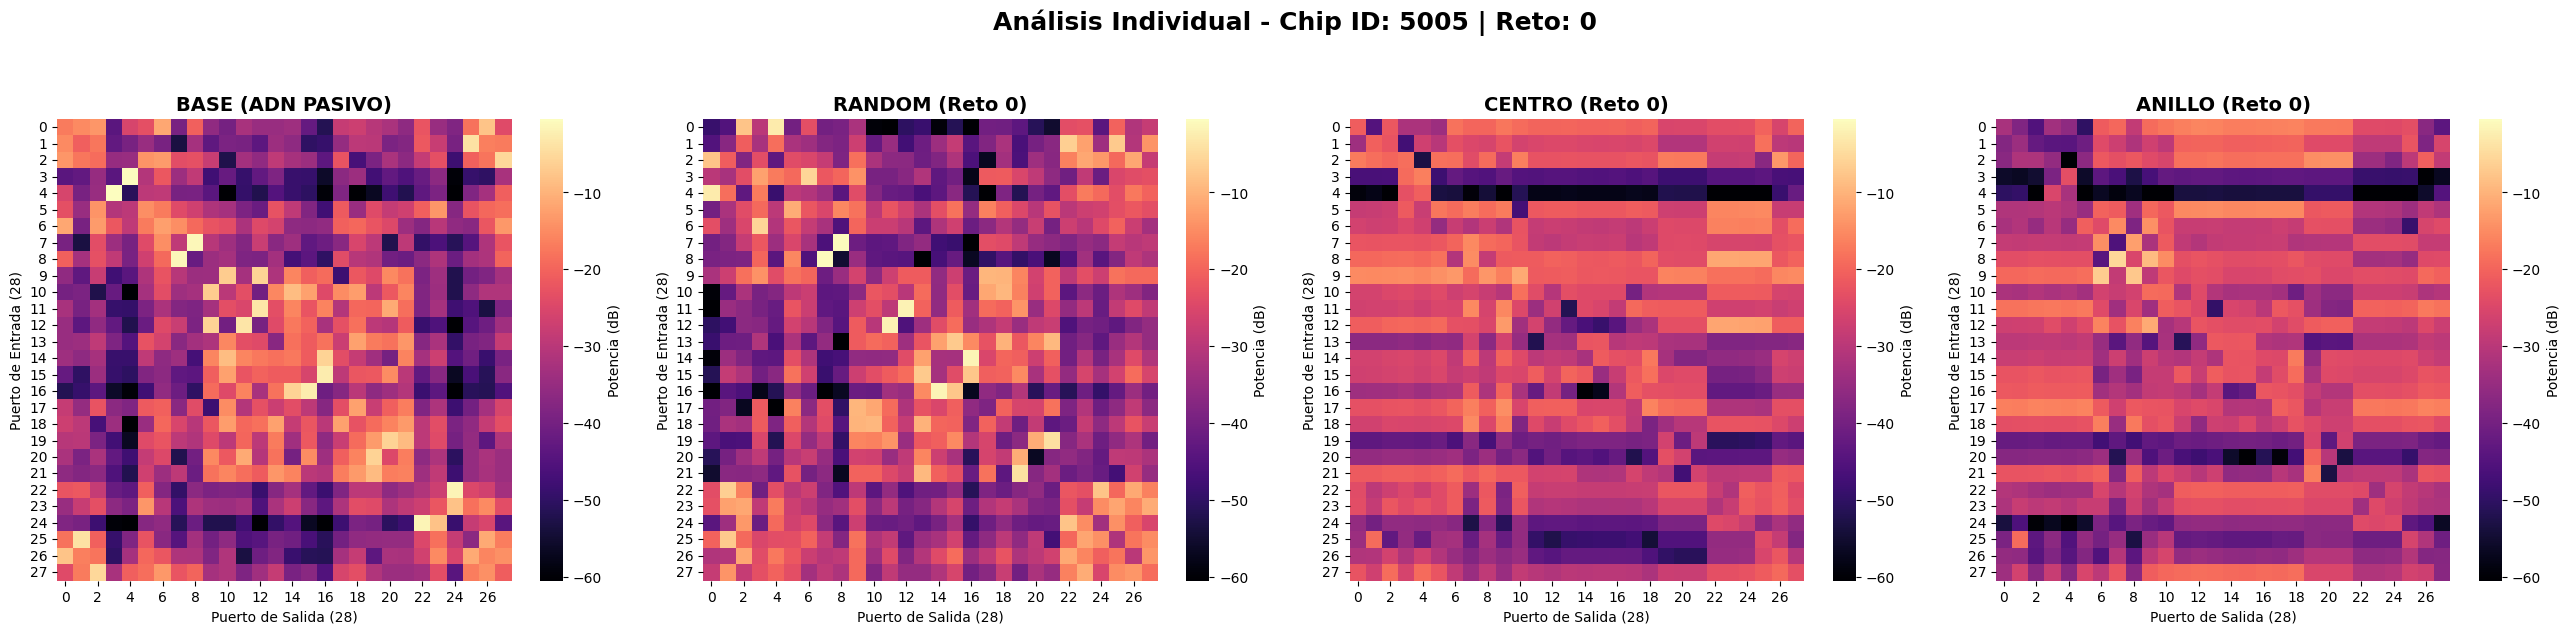

✅ Visualizando matrices de tamaño: (28, 28)
📊 Rango de potencia mostrado: -60.5 dB a -0.5 dB


In [129]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN DE VISUALIZACIÓN ---
directorio_data = "base_datos_puf_PRUEBA3" # Tu carpeta de pruebas
chip_a_ver = "chip_5005.npz"               # El primer chip generado
reto_idx = 0                               # El índice del reto (de 0 a 9)

# Cargar los datos
path_archivo = os.path.join(directorio_data, chip_a_ver)
if not os.path.exists(path_archivo):
    print(f"❌ No se encuentra el archivo {path_archivo}. ¡Asegúrate de haber corrido la simulación!")
else:
    data = np.load(path_archivo)
    
    # 1. Extraer matrices y pasar a dB (10*log10)
    # Nota: Usamos + 1e-12 para evitar log(0)
    m_base = 10 * np.log10(data['base'] + 1e-12)
    m_random = 10 * np.log10(data['random'][reto_idx] + 1e-12)
    m_centro = 10 * np.log10(data['centro'][reto_idx] + 1e-12)
    m_anillo = 10 * np.log10(data['anillo'][reto_idx] + 1e-12)

    escenarios_matrices = {
        "BASE (ADN PASIVO)": m_base,
        f"RANDOM (Reto {reto_idx})": m_random,
        f"CENTRO (Reto {reto_idx})": m_centro,
        f"ANILLO (Reto {reto_idx})": m_anillo
    }

    # --- 2. PLOTEO ---
    fig, axes = plt.subplots(1, 4, figsize=(26, 6))
    
    # Definir escala global para que todos los mapas sean comparables
    vmax = max([m.max() for m in escenarios_matrices.values()])
    vmin = vmax - 60  # Rango dinámico de 40dB para resaltar detalles

    for i, (titulo, matriz) in enumerate(escenarios_matrices.items()):
        ax = axes[i]
        sns.heatmap(matriz, ax=ax, cmap='magma', vmin=vmin, vmax=vmax,
                    cbar_kws={'label': 'Potencia (dB)'})
        
        ax.set_title(titulo, fontsize=14, fontweight='bold')
        ax.set_xlabel("Puerto de Salida (28)")
        ax.set_ylabel("Puerto de Entrada (28)")

    plt.suptitle(f"Análisis Individual - Chip ID: {data['seed_hw']} | Reto: {reto_idx}", 
                 fontsize=18, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()

    # Información extra sobre el tamaño
    print(f"✅ Visualizando matrices de tamaño: {m_base.shape}")
    print(f"📊 Rango de potencia mostrado: {vmin:.1f} dB a {vmax:.1f} dB")

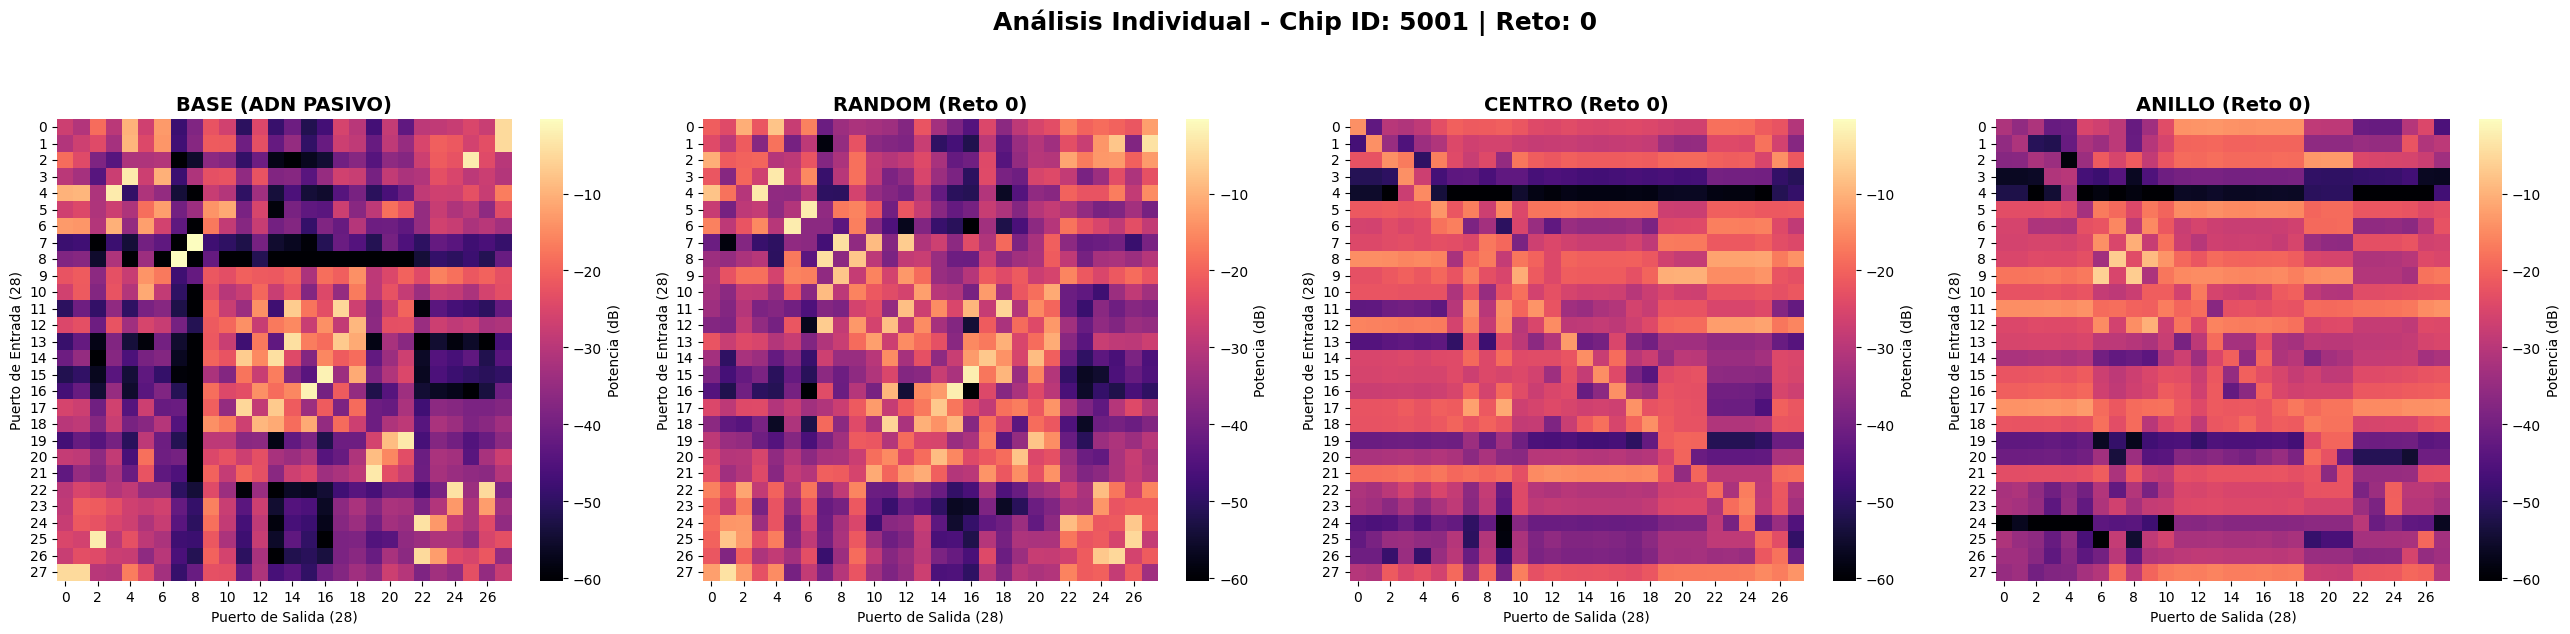

✅ Visualizando matrices de tamaño: (28, 28)
📊 Rango de potencia mostrado: -60.3 dB a -0.3 dB


In [127]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN DE VISUALIZACIÓN ---
directorio_data = "base_datos_puf_PRUEBA3" # Tu carpeta de pruebas
chip_a_ver = "chip_5001.npz"               # El primer chip generado
reto_idx = 0                              # El índice del reto (de 0 a 9)

# Cargar los datos
path_archivo = os.path.join(directorio_data, chip_a_ver)
if not os.path.exists(path_archivo):
    print(f"❌ No se encuentra el archivo {path_archivo}. ¡Asegúrate de haber corrido la simulación!")
else:
    data = np.load(path_archivo)
    
    # 1. Extraer matrices y pasar a dB (10*log10)
    # Nota: Usamos + 1e-12 para evitar log(0)
    m_base = 10 * np.log10(data['base'] + 1e-12)
    m_random = 10 * np.log10(data['random'][reto_idx] + 1e-12)
    m_centro = 10 * np.log10(data['centro'][reto_idx] + 1e-12)
    m_anillo = 10 * np.log10(data['anillo'][reto_idx] + 1e-12)

    escenarios_matrices = {
        "BASE (ADN PASIVO)": m_base,
        f"RANDOM (Reto {reto_idx})": m_random,
        f"CENTRO (Reto {reto_idx})": m_centro,
        f"ANILLO (Reto {reto_idx})": m_anillo
    }

    # --- 2. PLOTEO ---
    fig, axes = plt.subplots(1, 4, figsize=(26, 6))
    
    # Definir escala global para que todos los mapas sean comparables
    vmax = max([m.max() for m in escenarios_matrices.values()])
    vmin = vmax - 60  # Rango dinámico de 40dB para resaltar detalles

    for i, (titulo, matriz) in enumerate(escenarios_matrices.items()):
        ax = axes[i]
        sns.heatmap(matriz, ax=ax, cmap='magma', vmin=vmin, vmax=vmax,
                    cbar_kws={'label': 'Potencia (dB)'})
        
        ax.set_title(titulo, fontsize=14, fontweight='bold')
        ax.set_xlabel("Puerto de Salida (28)")
        ax.set_ylabel("Puerto de Entrada (28)")

    plt.suptitle(f"Análisis Individual - Chip ID: {data['seed_hw']} | Reto: {reto_idx}", 
                 fontsize=18, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()

    # Información extra sobre el tamaño
    print(f"✅ Visualizando matrices de tamaño: {m_base.shape}")
    print(f"📊 Rango de potencia mostrado: {vmin:.1f} dB a {vmax:.1f} dB")

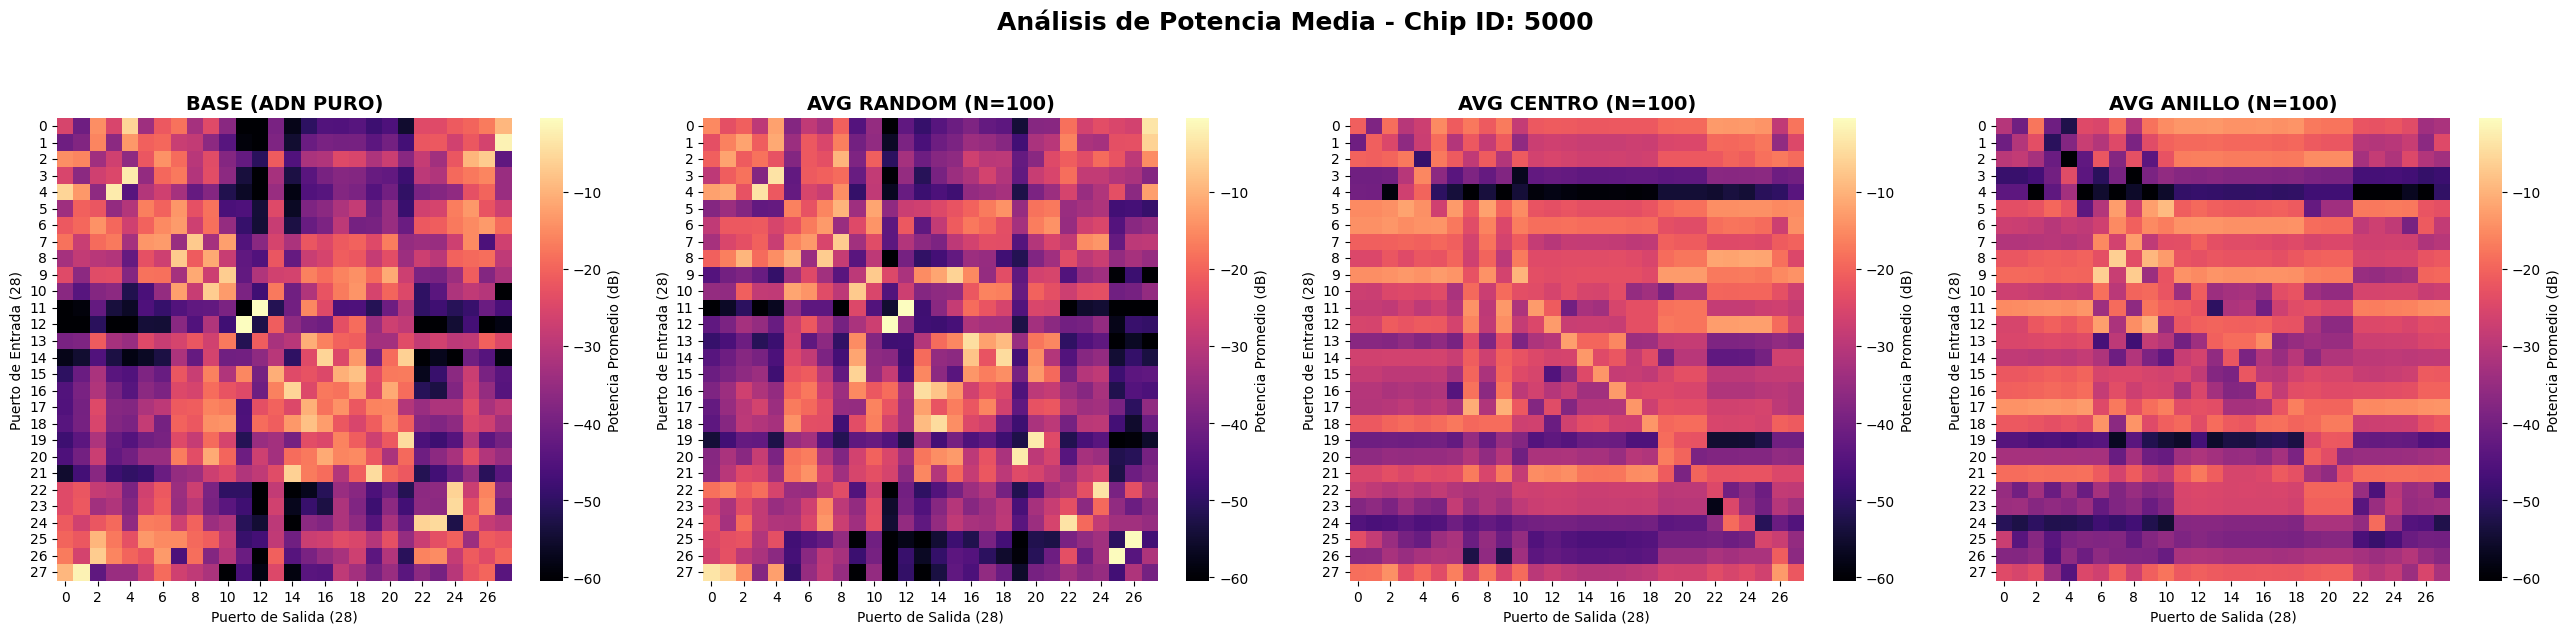

✅ Promedio calculado sobre 100 retos.
📊 Rango de potencia visualizado: -60.4 dB a -0.4 dB


In [123]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN DE VISUALIZACIÓN ---
directorio_data = "base_datos_puf_PRUEBA3" # Ajusta a tu carpeta actual
chip_a_ver = "chip_5000.npz" 
n_retos_media = 100  # Número de retos para promediar

# Cargar los datos
path_archivo = os.path.join(directorio_data, chip_a_ver)

if not os.path.exists(path_archivo):
    print(f"❌ No se encuentra el archivo {path_archivo}.")
else:
    data = np.load(path_archivo)
    
    # 1. Calcular la MEDIA LINEAL de los primeros N retos
    # La forma de data['random'] es (num_retos, 28, 28)
    # Hacemos la media sobre el eje 0 (los retos)
    p_media_random = np.mean(data['random'][:n_retos_media], axis=0)
    p_media_centro = np.mean(data['centro'][:n_retos_media], axis=0)
    p_media_anillo = np.mean(data['anillo'][:n_retos_media], axis=0)
    
    # 2. Pasar a escala logarítmica (dB)
    m_base = 10 * np.log10(data['base'] + 1e-12)
    m_avg_random = 10 * np.log10(p_media_random + 1e-12)
    m_avg_centro = 10 * np.log10(p_media_centro + 1e-12)
    m_avg_anillo = 10 * np.log10(p_media_anillo + 1e-12)

    escenarios_matrices = {
        "BASE (ADN PURO)": m_base,
        f"AVG RANDOM (N={n_retos_media})": m_avg_random,
        f"AVG CENTRO (N={n_retos_media})": m_avg_centro,
        f"AVG ANILLO (N={n_retos_media})": m_avg_anillo
    }

    # --- 3. PLOTEO ---
    fig, axes = plt.subplots(1, 4, figsize=(26, 6))
    
    # Escala global para comparar
    vmax = max([m.max() for m in escenarios_matrices.values()])
    vmin = vmax - 60  # Rango dinámico de 50dB

    for i, (titulo, matriz) in enumerate(escenarios_matrices.items()):
        ax = axes[i]
        sns.heatmap(matriz, ax=ax, cmap='magma', vmin=vmin, vmax=vmax,
                    cbar_kws={'label': 'Potencia Promedio (dB)'})
        
        ax.set_title(titulo, fontsize=14, fontweight='bold')
        ax.set_xlabel("Puerto de Salida (28)")
        ax.set_ylabel("Puerto de Entrada (28)")

    plt.suptitle(f"Análisis de Potencia Media - Chip ID: {data['seed_hw']}", 
                 fontsize=18, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()

    print(f"✅ Promedio calculado sobre {n_retos_media} retos.")
    print(f"📊 Rango de potencia visualizado: {vmin:.1f} dB a {vmax:.1f} dB")

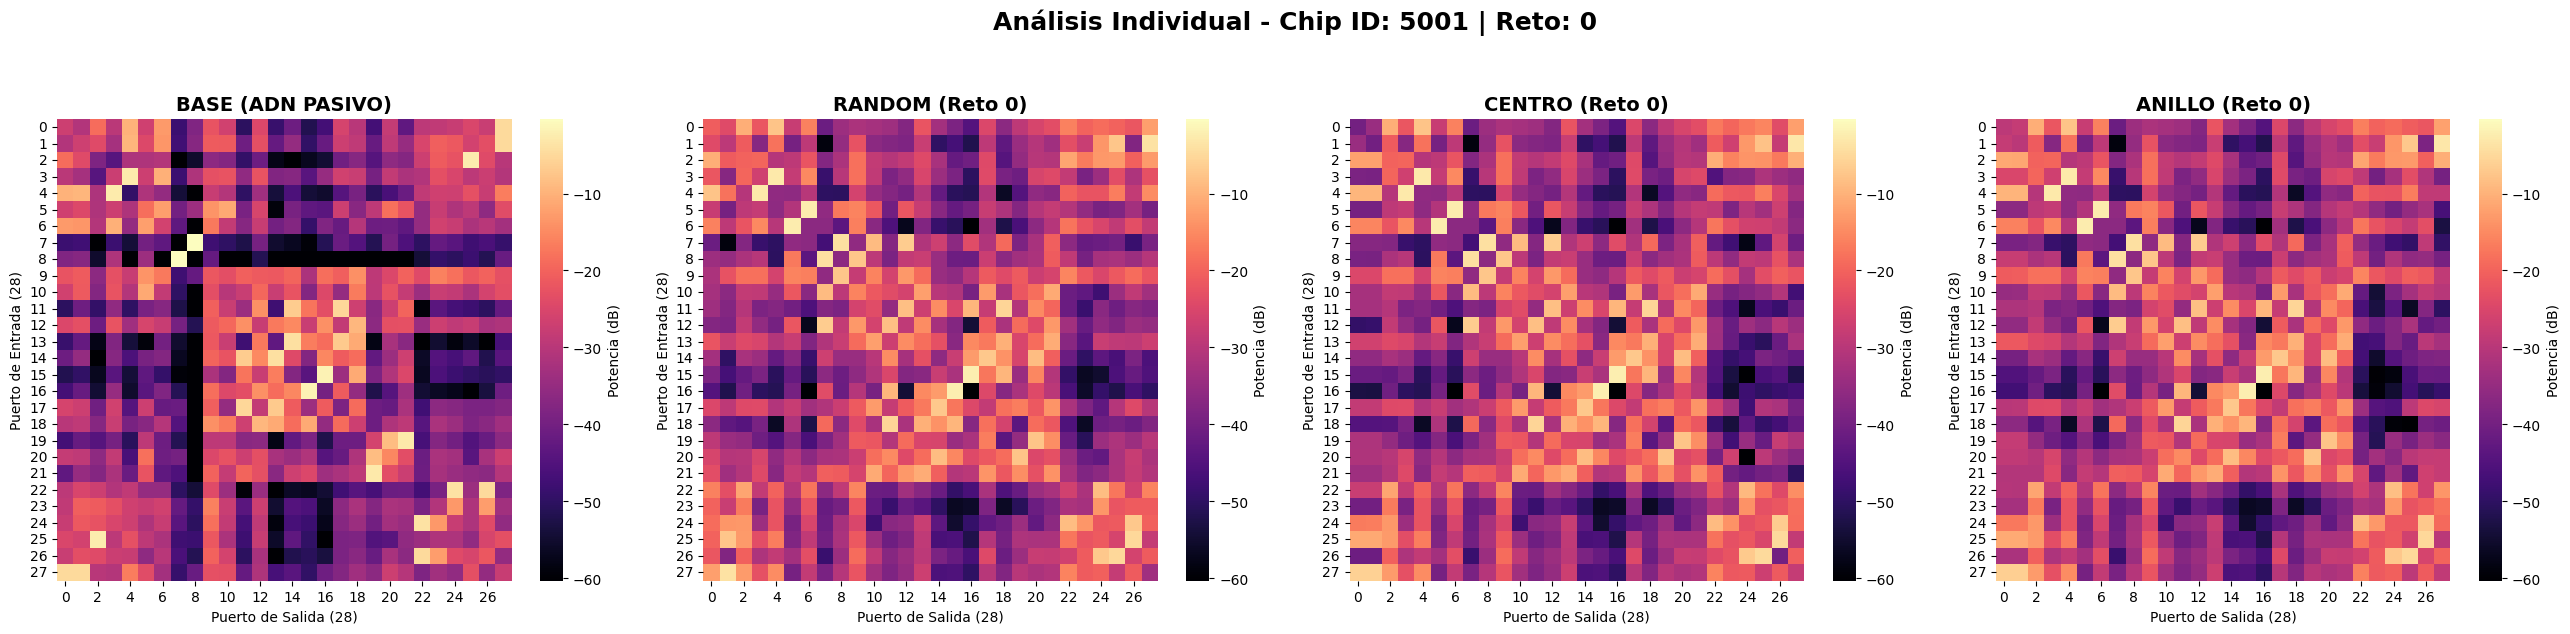

✅ Visualizando matrices de tamaño: (28, 28)
📊 Rango de potencia mostrado: -60.3 dB a -0.3 dB


In [30]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN DE VISUALIZACIÓN ---
directorio_data = "base_datos_puf_PRUEBA1" # Tu carpeta de pruebas
chip_a_ver = "chip_5001.npz"               # El primer chip generado
reto_idx = 0                               # El índice del reto (de 0 a 9)

# Cargar los datos
path_archivo = os.path.join(directorio_data, chip_a_ver)
if not os.path.exists(path_archivo):
    print(f"❌ No se encuentra el archivo {path_archivo}. ¡Asegúrate de haber corrido la simulación!")
else:
    data = np.load(path_archivo)
    
    # 1. Extraer matrices y pasar a dB (10*log10)
    # Nota: Usamos + 1e-12 para evitar log(0)
    m_base = 10 * np.log10(data['base'] + 1e-12)
    m_random = 10 * np.log10(data['random'][reto_idx] + 1e-12)
    m_centro = 10 * np.log10(data['centro'][reto_idx] + 1e-12)
    m_anillo = 10 * np.log10(data['anillo'][reto_idx] + 1e-12)

    escenarios_matrices = {
        "BASE (ADN PASIVO)": m_base,
        f"RANDOM (Reto {reto_idx})": m_random,
        f"CENTRO (Reto {reto_idx})": m_centro,
        f"ANILLO (Reto {reto_idx})": m_anillo
    }

    # --- 2. PLOTEO ---
    fig, axes = plt.subplots(1, 4, figsize=(26, 6))
    
    # Definir escala global para que todos los mapas sean comparables
    vmax = max([m.max() for m in escenarios_matrices.values()])
    vmin = vmax - 60  # Rango dinámico de 40dB para resaltar detalles

    for i, (titulo, matriz) in enumerate(escenarios_matrices.items()):
        ax = axes[i]
        sns.heatmap(matriz, ax=ax, cmap='magma', vmin=vmin, vmax=vmax,
                    cbar_kws={'label': 'Potencia (dB)'})
        
        ax.set_title(titulo, fontsize=14, fontweight='bold')
        ax.set_xlabel("Puerto de Salida (28)")
        ax.set_ylabel("Puerto de Entrada (28)")

    plt.suptitle(f"Análisis Individual - Chip ID: {data['seed_hw']} | Reto: {reto_idx}", 
                 fontsize=18, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()

    # Información extra sobre el tamaño
    print(f"✅ Visualizando matrices de tamaño: {m_base.shape}")
    print(f"📊 Rango de potencia mostrado: {vmin:.1f} dB a {vmax:.1f} dB")


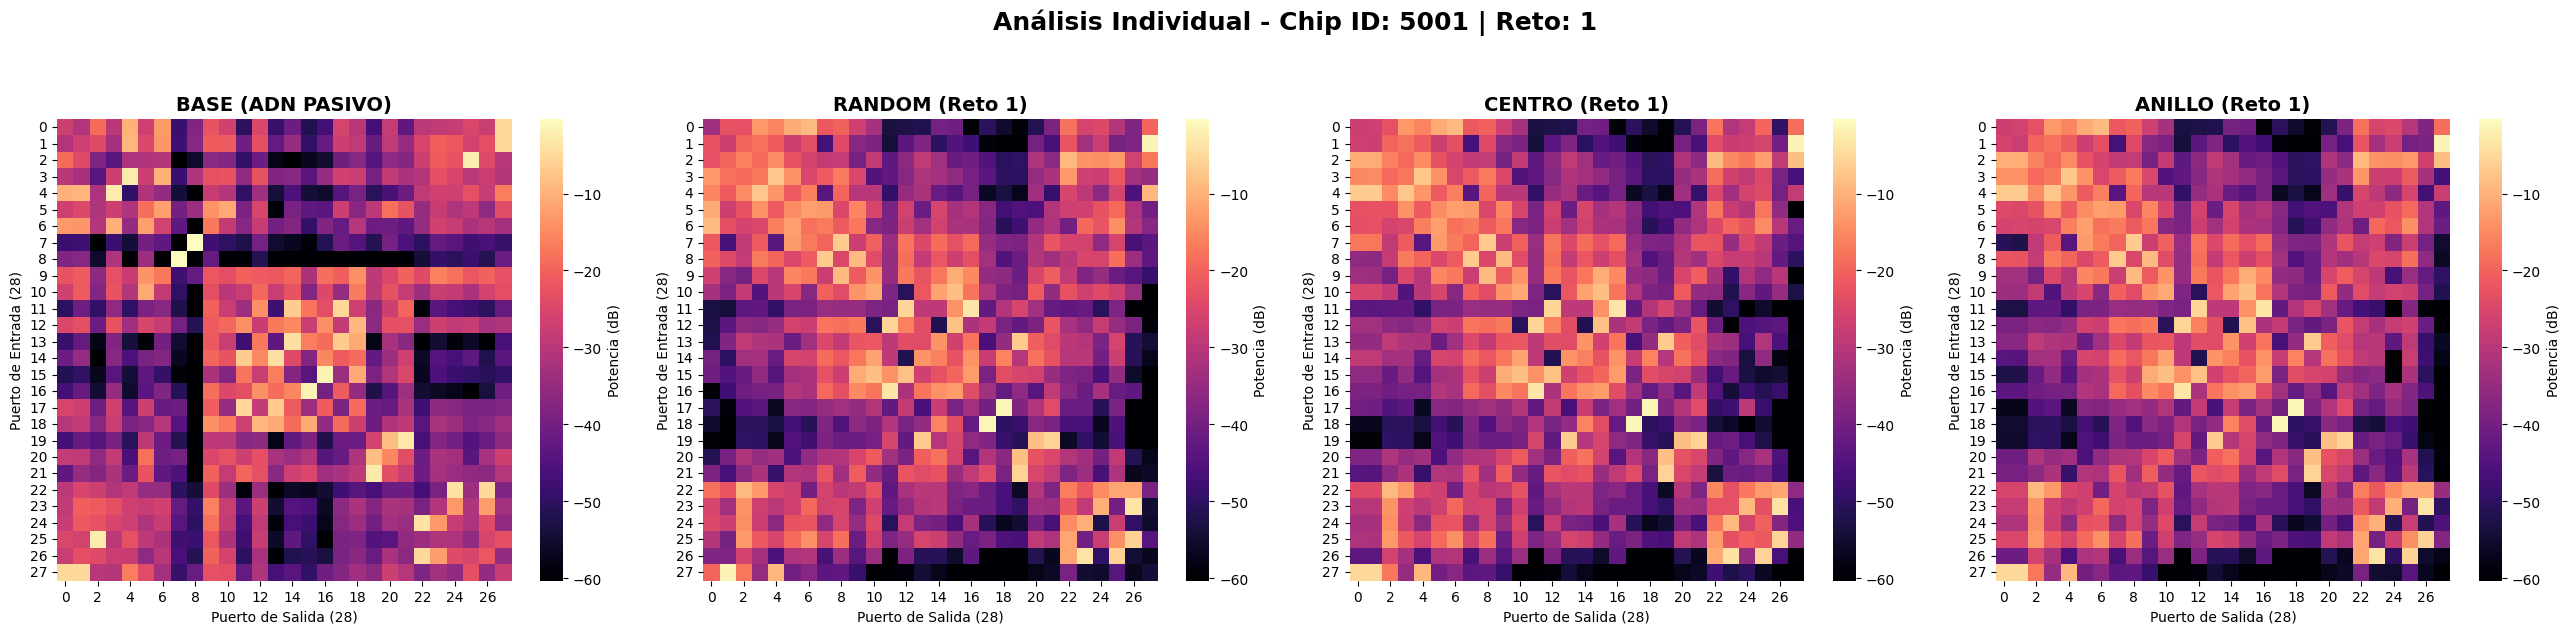

✅ Visualizando matrices de tamaño: (28, 28)
📊 Rango de potencia mostrado: -60.3 dB a -0.3 dB


In [31]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN DE VISUALIZACIÓN ---
directorio_data = "base_datos_puf_PRUEBA1" # Tu carpeta de pruebas
chip_a_ver = "chip_5001.npz"               # El primer chip generado
reto_idx = 1                               # El índice del reto (de 0 a 9)

# Cargar los datos
path_archivo = os.path.join(directorio_data, chip_a_ver)
if not os.path.exists(path_archivo):
    print(f"❌ No se encuentra el archivo {path_archivo}. ¡Asegúrate de haber corrido la simulación!")
else:
    data = np.load(path_archivo)
    
    # 1. Extraer matrices y pasar a dB (10*log10)
    # Nota: Usamos + 1e-12 para evitar log(0)
    m_base = 10 * np.log10(data['base'] + 1e-12)
    m_random = 10 * np.log10(data['random'][reto_idx] + 1e-12)
    m_centro = 10 * np.log10(data['centro'][reto_idx] + 1e-12)
    m_anillo = 10 * np.log10(data['anillo'][reto_idx] + 1e-12)

    escenarios_matrices = {
        "BASE (ADN PASIVO)": m_base,
        f"RANDOM (Reto {reto_idx})": m_random,
        f"CENTRO (Reto {reto_idx})": m_centro,
        f"ANILLO (Reto {reto_idx})": m_anillo
    }

    # --- 2. PLOTEO ---
    fig, axes = plt.subplots(1, 4, figsize=(26, 6))
    
    # Definir escala global para que todos los mapas sean comparables
    vmax = max([m.max() for m in escenarios_matrices.values()])
    vmin = vmax - 60  # Rango dinámico de 40dB para resaltar detalles

    for i, (titulo, matriz) in enumerate(escenarios_matrices.items()):
        ax = axes[i]
        sns.heatmap(matriz, ax=ax, cmap='magma', vmin=vmin, vmax=vmax,
                    cbar_kws={'label': 'Potencia (dB)'})
        
        ax.set_title(titulo, fontsize=14, fontweight='bold')
        ax.set_xlabel("Puerto de Salida (28)")
        ax.set_ylabel("Puerto de Entrada (28)")

    plt.suptitle(f"Análisis Individual - Chip ID: {data['seed_hw']} | Reto: {reto_idx}", 
                 fontsize=18, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()

    # Información extra sobre el tamaño
    print(f"✅ Visualizando matrices de tamaño: {m_base.shape}")
    print(f"📊 Rango de potencia mostrado: {vmin:.1f} dB a {vmax:.1f} dB")


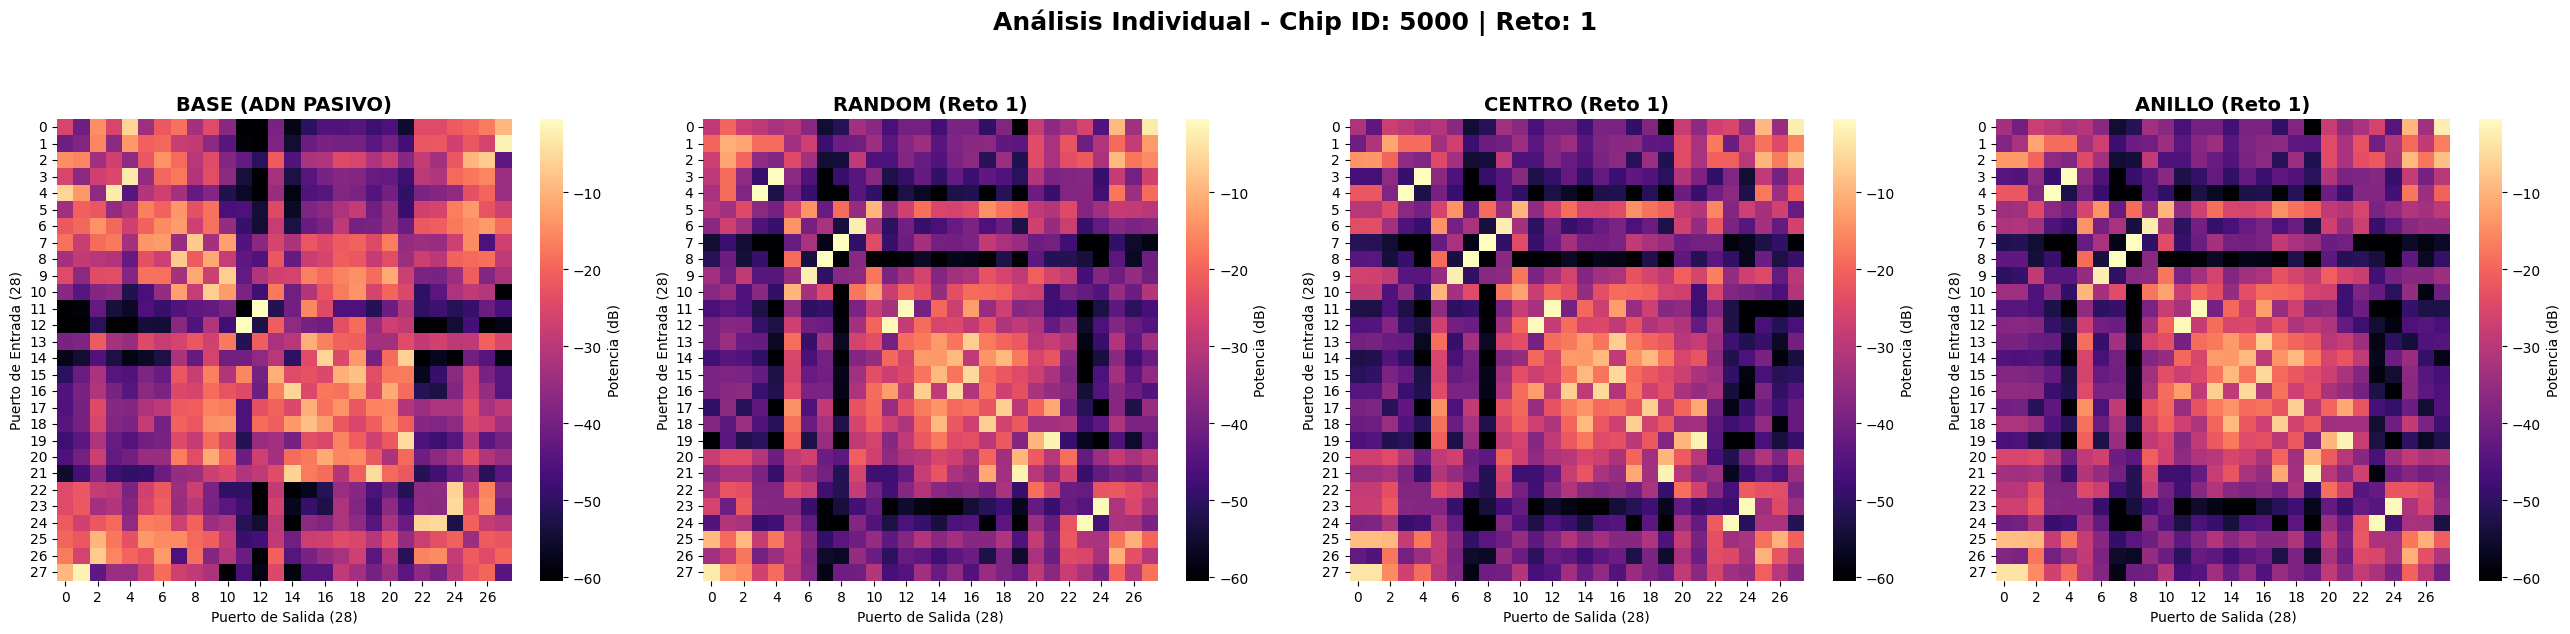

✅ Visualizando matrices de tamaño: (28, 28)
📊 Rango de potencia mostrado: -60.4 dB a -0.4 dB


In [32]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN DE VISUALIZACIÓN ---
directorio_data = "base_datos_puf_PRUEBA1" # Tu carpeta de pruebas
chip_a_ver = "chip_5000.npz"               # El primer chip generado
reto_idx = 1                               # El índice del reto (de 0 a 9)

# Cargar los datos
path_archivo = os.path.join(directorio_data, chip_a_ver)
if not os.path.exists(path_archivo):
    print(f"❌ No se encuentra el archivo {path_archivo}. ¡Asegúrate de haber corrido la simulación!")
else:
    data = np.load(path_archivo)
    
    # 1. Extraer matrices y pasar a dB (10*log10)
    # Nota: Usamos + 1e-12 para evitar log(0)
    m_base = 10 * np.log10(data['base'] + 1e-12)
    m_random = 10 * np.log10(data['random'][reto_idx] + 1e-12)
    m_centro = 10 * np.log10(data['centro'][reto_idx] + 1e-12)
    m_anillo = 10 * np.log10(data['anillo'][reto_idx] + 1e-12)

    escenarios_matrices = {
        "BASE (ADN PASIVO)": m_base,
        f"RANDOM (Reto {reto_idx})": m_random,
        f"CENTRO (Reto {reto_idx})": m_centro,
        f"ANILLO (Reto {reto_idx})": m_anillo
    }

    # --- 2. PLOTEO ---
    fig, axes = plt.subplots(1, 4, figsize=(26, 6))
    
    # Definir escala global para que todos los mapas sean comparables
    vmax = max([m.max() for m in escenarios_matrices.values()])
    vmin = vmax - 60  # Rango dinámico de 40dB para resaltar detalles

    for i, (titulo, matriz) in enumerate(escenarios_matrices.items()):
        ax = axes[i]
        sns.heatmap(matriz, ax=ax, cmap='magma', vmin=vmin, vmax=vmax,
                    cbar_kws={'label': 'Potencia (dB)'})
        
        ax.set_title(titulo, fontsize=14, fontweight='bold')
        ax.set_xlabel("Puerto de Salida (28)")
        ax.set_ylabel("Puerto de Entrada (28)")

    plt.suptitle(f"Análisis Individual - Chip ID: {data['seed_hw']} | Reto: {reto_idx}", 
                 fontsize=18, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()

    # Información extra sobre el tamaño
    print(f"✅ Visualizando matrices de tamaño: {m_base.shape}")
    print(f"📊 Rango de potencia mostrado: {vmin:.1f} dB a {vmax:.1f} dB")


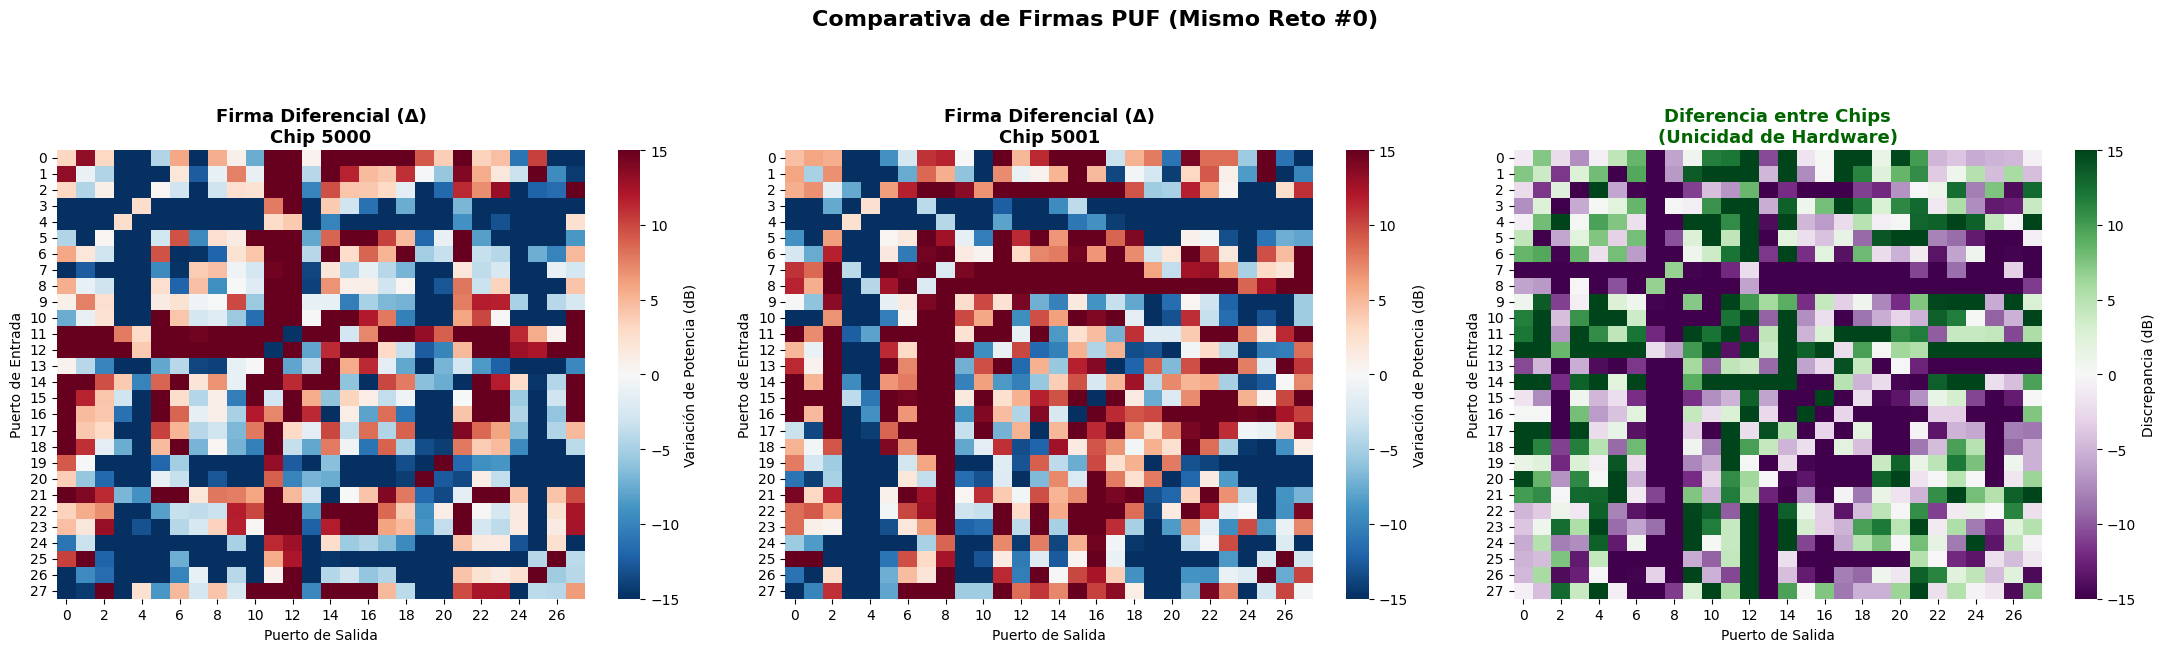

📊 Correlación entre las firmas de ambos chips: 0.5215
⚠️ BAJA UNICIDAD: Los chips se comportan de forma similar.


In [87]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# --- CONFIGURACIÓN ---
directorio_data = "base_datos_puf_PRUEBA8"
reto_idx = 0  # Usamos el mismo reto para ambos
chip_ids = [5000, 5001]

def obtener_delta(chip_id, idx):
    path = os.path.join(directorio_data, f"chip_{chip_id}.npz")
    data = np.load(path)
    # Pasamos a dB
    m_base = 10 * np.log10(data['base'] + 1e-12)
    m_random = 10 * np.log10(data['random'][idx] + 1e-12)
    # Calculamos la firma diferencial: Delta = Challenge - Base
    return m_random - m_base

# 1. Obtener los Deltas
delta_a = obtener_delta(chip_ids[0], reto_idx)
delta_b = obtener_delta(chip_ids[1], reto_idx)

# 2. Calcular la diferencia entre deltas (La "Firma de Hardware" pura)
# Si los chips fueran iguales, esta matriz sería cero.
diferencia_inter_chip = delta_a - delta_b

# --- 3. PLOTEO ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Escala para deltas (suelen oscilar entre -20 y +20 dB)
vlim = 15 

# Chip A
sns.heatmap(delta_a, ax=axes[0], cmap='RdBu_r', center=0, vmin=-vlim, vmax=vlim,
            cbar_kws={'label': 'Variación de Potencia (dB)'})
axes[0].set_title(f"Firma Diferencial (Δ)\nChip {chip_ids[0]}", fontsize=13, fontweight='bold')

# Chip B
sns.heatmap(delta_b, ax=axes[1], cmap='RdBu_r', center=0, vmin=-vlim, vmax=vlim,
            cbar_kws={'label': 'Variación de Potencia (dB)'})
axes[1].set_title(f"Firma Diferencial (Δ)\nChip {chip_ids[1]}", fontsize=13, fontweight='bold')

# Diferencia entre ambos (Unicidad)
sns.heatmap(diferencia_inter_chip, ax=axes[2], cmap='PRGn', center=0, vmin=-vlim, vmax=vlim,
            cbar_kws={'label': 'Discrepancia (dB)'})
axes[2].set_title("Diferencia entre Chips\n(Unicidad de Hardware)", fontsize=13, fontweight='bold', color='darkgreen')

for ax in axes:
    ax.set_xlabel("Puerto de Salida")
    ax.set_ylabel("Puerto de Entrada")

plt.suptitle(f"Comparativa de Firmas PUF (Mismo Reto #{reto_idx})", fontsize=16, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

# --- 4. MÉTRICA DE UNICIDAD ---
corr, _ = pearsonr(delta_a.flatten(), delta_b.flatten())
print(f"📊 Correlación entre las firmas de ambos chips: {corr:.4f}")
if corr < 0.3:
    print("✅ EXCELENTE UNICIDAD: Las huellas dactilares son casi independientes.")
else:
    print("⚠️ BAJA UNICIDAD: Los chips se comportan de forma similar.")

📂 Cargando y procesando 100 chips...


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 86.12it/s]


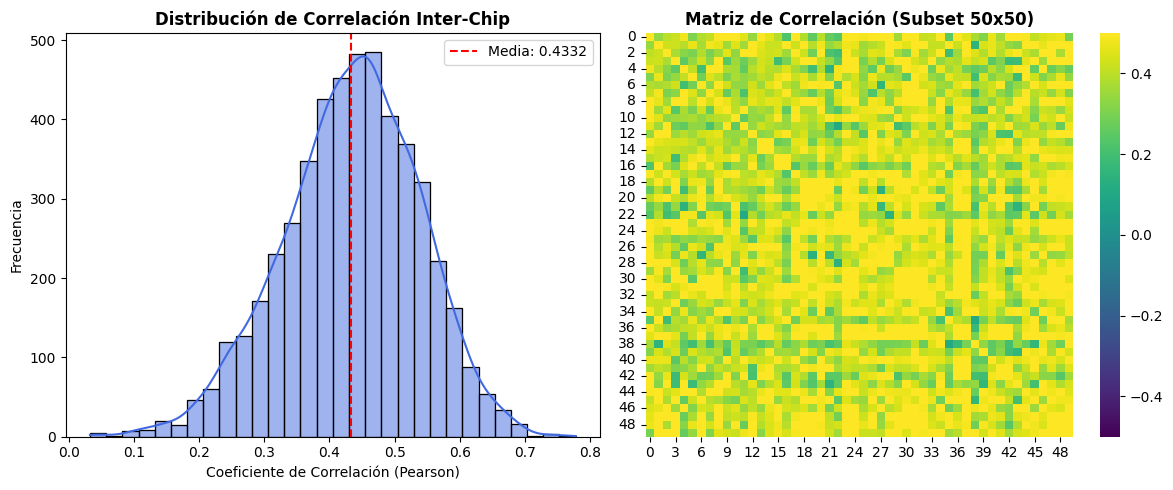

------------------------------
📈 RESULTADOS ESTADÍSTICOS (N=100):
  > Correlación Media: 0.4332
  > Desviación Estándar (σ): 0.1047
  > Valor Máximo: 0.7778
  > Valor Mínimo: 0.0325
------------------------------


In [140]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from tqdm import tqdm

# --- CONFIGURACIÓN ---
directorio_data = "base_datos_puf_PRUEBA4"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])[:100]

firmas = []

print(f"📂 Cargando y procesando {len(archivos)} chips...")
for f in tqdm(archivos):
    data = np.load(os.path.join(directorio_data, f))
    
    # Usamos la firma diferencial (Delta) para eliminar el sesgo estructural
    # Delta = 10*log10(Random) - 10*log10(Base)
    m_base = 10 * np.log10(data['base'] + 1e-12)
    m_random = 10 * np.log10(data['random'][0] + 1e-12) # Solo hay 1 reto
    
    delta = (m_random ).flatten()
    firmas.append(delta)

# Convertimos a matriz (100 chips x 784 puntos)
matriz_firmas = np.array(firmas)

# 1. Calcular Matriz de Correlación de Pearson (100x100)
corr_matrix = np.corrcoef(matriz_firmas)

# 2. Extraer solo los valores de la diagonal superior (comparaciones entre chips distintos)
# Evitamos la diagonal principal (correlación de un chip consigo mismo = 1)
indices_sup = np.triu_indices_from(corr_matrix, k=1)
valores_corr = corr_matrix[indices_sup]

# --- 3. MÉTRICAS Y VISUALIZACIÓN ---
mu = np.mean(valores_corr)
sigma = np.std(valores_corr)

plt.figure(figsize=(12, 5))

# Plot 1: Histograma de Correlaciones
plt.subplot(1, 2, 1)
sns.histplot(valores_corr, kde=True, color='royalblue', bins=30)
plt.axvline(mu, color='red', linestyle='--', label=f'Media: {mu:.4f}')
plt.title("Distribución de Correlación Inter-Chip", fontweight='bold')
plt.xlabel("Coeficiente de Correlación (Pearson)")
plt.ylabel("Frecuencia")
plt.legend()

# Plot 2: Mapa de calor de la matriz (primeros 50 para que se vea bien)
plt.subplot(1, 2, 2)
sns.heatmap(corr_matrix[:50, :50], cmap='viridis', vmin=-0.5, vmax=0.5)
plt.title("Matriz de Correlación (Subset 50x50)", fontweight='bold')

plt.tight_layout()
plt.show()

print("-" * 30)
print(f"📈 RESULTADOS ESTADÍSTICOS (N={len(archivos)}):")
print(f"  > Correlación Media: {mu:.4f}")
print(f"  > Desviación Estándar (σ): {sigma:.4f}")
print(f"  > Valor Máximo: {np.max(valores_corr):.4f}")
print(f"  > Valor Mínimo: {np.min(valores_corr):.4f}")
print("-" * 30)

📂 Procesando 100 chips con Firma Diferencial (Δ)...


Escenario ANILLO: 100%|████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1123.35it/s]
C:\Users\Cristina\AppData\Local\Temp\ipykernel_38104\1513082662.py:68: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Cristina\AppData\Local\Temp\ipykernel_38104\1513082662.py:68: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Cristina\AppData\Local\Temp\ipykernel_38104\1513082662.py:68: UserWarning: Glyph 12305 (\N{RIGHT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 

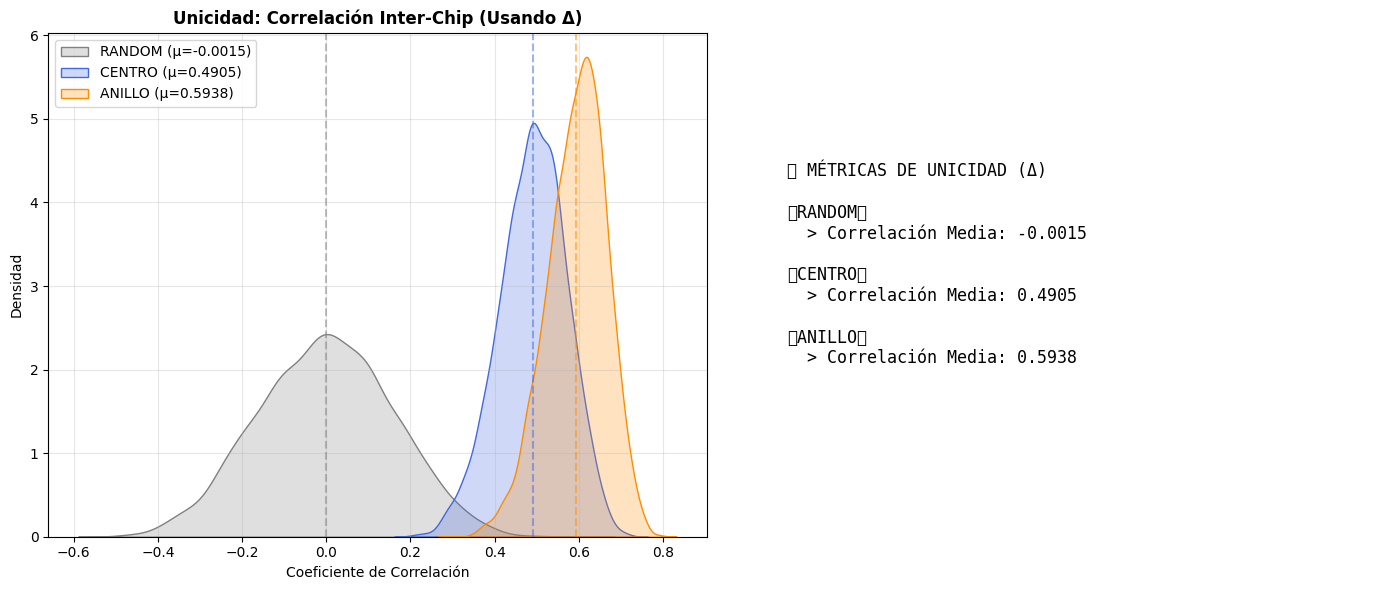

------------------------------------------------------------
ESCENARIO       | MEDIA CORR | MAX CORR  
------------------------------------------------------------
RANDOM          |    -0.0015 |     0.5980
CENTRO          |     0.4905 |     0.7214
ANILLO          |     0.5938 |     0.7942
------------------------------------------------------------


In [142]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- CONFIGURACIÓN ---
directorio_data = "base_datos_puf_PRUEBA4" 
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])[:100]

escenarios = ['random', 'centro', 'anillo']
colores = {'random': 'gray', 'centro': 'royalblue', 'anillo': 'darkorange'}
resultados_unicidad = {}

print(f"📂 Procesando {len(archivos)} chips con Firma Diferencial (Δ)...")

for esc in escenarios:
    firmas = []
    for f in tqdm(archivos, desc=f"Escenario {esc.upper()}"):
        data = np.load(os.path.join(directorio_data, f))
        
        # 1. Calculamos las potencias en dB
        # Nota: data['base'] es la huella en reposo
        # data[esc][0] es la respuesta al reto
        db_base = 10 * np.log10(data['base'] + 1e-12)
        db_reto = 10 * np.log10(data[esc][0] + 1e-12)
        
        # 2. GENERACIÓN DE LA FIRMA DIFERENCIAL (Δ)
        # Esto elimina el patrón común del anillo y deja el ADN residual
        delta = (db_base - db_reto ).flatten()
        
        firmas.append(delta)

    # Convertimos a matriz (N_chips x 784 puntos)
    matriz_firmas = np.array(firmas)

    # 3. Calcular Matriz de Correlación de Pearson
    corr_matrix = np.corrcoef(matriz_firmas)

    # 4. Extraer valores de la diagonal superior
    indices_sup = np.triu_indices_from(corr_matrix, k=1)
    resultados_unicidad[esc] = corr_matrix[indices_sup]

# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for esc in escenarios:
    sns.kdeplot(resultados_unicidad[esc], fill=True, 
                label=f"{esc.upper()} (μ={np.mean(resultados_unicidad[esc]):.4f})", 
                color=colores[esc])
    plt.axvline(np.mean(resultados_unicidad[esc]), color=colores[esc], linestyle='--', alpha=0.5)

plt.title("Unicidad: Correlación Inter-Chip (Usando Δ)", fontweight='bold')
plt.xlabel("Coeficiente de Correlación")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.axis('off')
texto_resumen = "📈 MÉTRICAS DE UNICIDAD (Δ)\n\n"
for esc in escenarios:
    mu = np.mean(resultados_unicidad[esc])
    texto_resumen += f"【{esc.upper()}】\n  > Correlación Media: {mu:.4f}\n\n"

plt.text(0.1, 0.5, texto_resumen, fontsize=12, family='monospace', va='center')
plt.tight_layout()
plt.show()

print("-" * 60)
print(f"{'ESCENARIO':<15} | {'MEDIA CORR':<10} | {'MAX CORR':<10}")
print("-" * 60)
for esc in escenarios:
    vals = resultados_unicidad[esc]
    print(f"{esc.upper():<15} | {np.mean(vals):>10.4f} | {np.max(vals):>10.4f}")
print("-" * 60)

In [40]:
# --- CONFIGURACIÓN ---
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla_test = malla_SNM_completa(tbus_columnas, seed=123)
ids_40 = malla_test.obtener_ids_perimetrales_ordenados()

# Filtramos para quedarnos con tus 28 puertos activos
#ids_activos = [ids_40[i] for i in range(40) if i < 22 or i > 33]

n_chips = 1
num_retos = 100
directorio_data = "base_datos_puf_1CHIP_1000RETOS"
n_jobs = -1

# --- BUCLE PRINCIPAL ---
print(f"🚀 Iniciando simulación masiva: {n_chips} chips x {num_retos} retos...")
for c in tqdm(range(n_chips), desc="Progreso de Chips"):
    # IMPORTANTE: Añadimos 'num_retos' al final de la llamada 👇
    ejecutar_y_guardar_chip(c, tbus_columnas, ids_activos, 
                            rutas_maestras_anillo, rutas_maestras, num_retos)

print(f"✅ Simulación y almacenamiento completado en '{directorio_data}/'.")

🚀 Iniciando simulación masiva: 1 chips x 100 retos...


Progreso de Chips: 100%|█████████████████████████████████████████████████████████████████| 1/1 [00:08<00:00,  8.75s/it]

✅ Simulación y almacenamiento completado en 'base_datos_puf_1CHIP_1000RETOS/'.


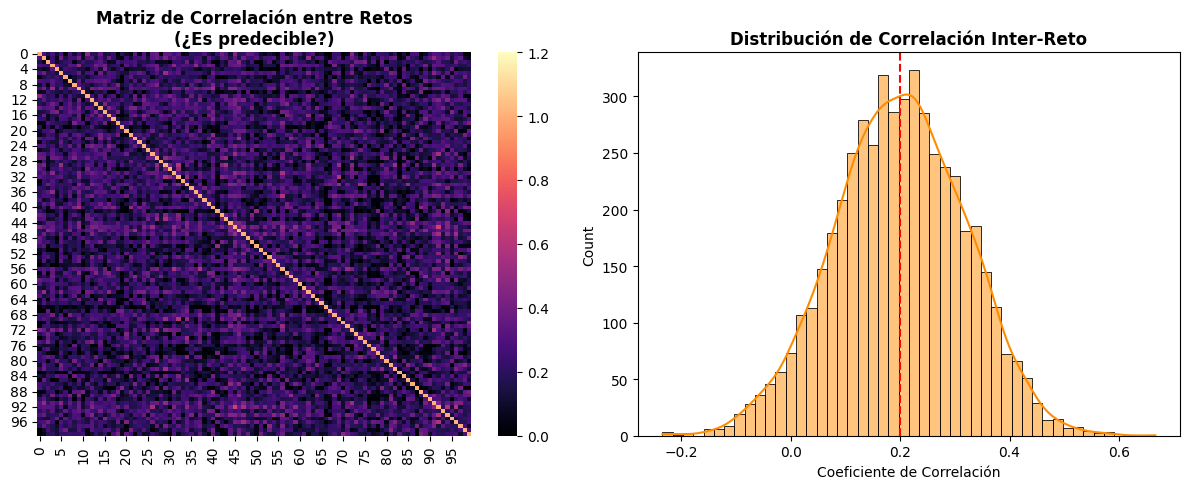

📈 MEDIA DE CORRELACIÓN ENTRE RETOS: 0.1990
📉 VALOR MÁXIMO DE SIMILITUD: 0.6664


In [119]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- CONFIGURACIÓN ---
directorio_data = "base_datos_puf_PRUEBA1"
archivo_chip = "chip_5000.npz" # El chip que acabas de simular

path = os.path.join(directorio_data, archivo_chip)
data = np.load(path)

# 1. Extraer todos los retos (Deltas)
# m_random tiene dimensiones (100, 28, 28)
m_base = 10 * np.log10(data['base'] + 1e-12)
firmas_retos = []

for i in range(len(data['anillo'])):
    m_random = 10 * np.log10(data['anillo'][i] + 1e-12)
    delta = (m_random).flatten()
    firmas_retos.append(delta)

matriz_retos = np.array(firmas_retos) # (100 retos x 784 puntos)

# 2. Calcular Matriz de Correlación entre Retos (100x100)
corr_matrix_retos = np.corrcoef(matriz_retos)

# 3. Extraer valores fuera de la diagonal
indices_sup = np.triu_indices_from(corr_matrix_retos, k=1)
valores_corr_retos = corr_matrix_retos[indices_sup]

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix_retos, cmap='magma', vmin=0, vmax=1.2)
plt.title("Matriz de Correlación entre Retos\n(¿Es predecible?)", fontweight='bold')

plt.subplot(1, 2, 2)
sns.histplot(valores_corr_retos, kde=True, color='darkorange')
plt.axvline(np.mean(valores_corr_retos), color='red', linestyle='--')
plt.title("Distribución de Correlación Inter-Reto", fontweight='bold')
plt.xlabel("Coeficiente de Correlación")

plt.tight_layout()
plt.show()

print(f"📈 MEDIA DE CORRELACIÓN ENTRE RETOS: {np.mean(valores_corr_retos):.4f}")
print(f"📉 VALOR MÁXIMO DE SIMILITUD: {np.max(valores_corr_retos):.4f}")

<>:58: SyntaxWarning: invalid escape sequence '\D'
<>:58: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Cristina\AppData\Local\Temp\ipykernel_38104\150914912.py:58: SyntaxWarning: invalid escape sequence '\D'
  plt.title("Efecto Avalancha: Independencia de Firmas Diferenciales ($\Delta$)", fontsize=14, fontweight='bold')


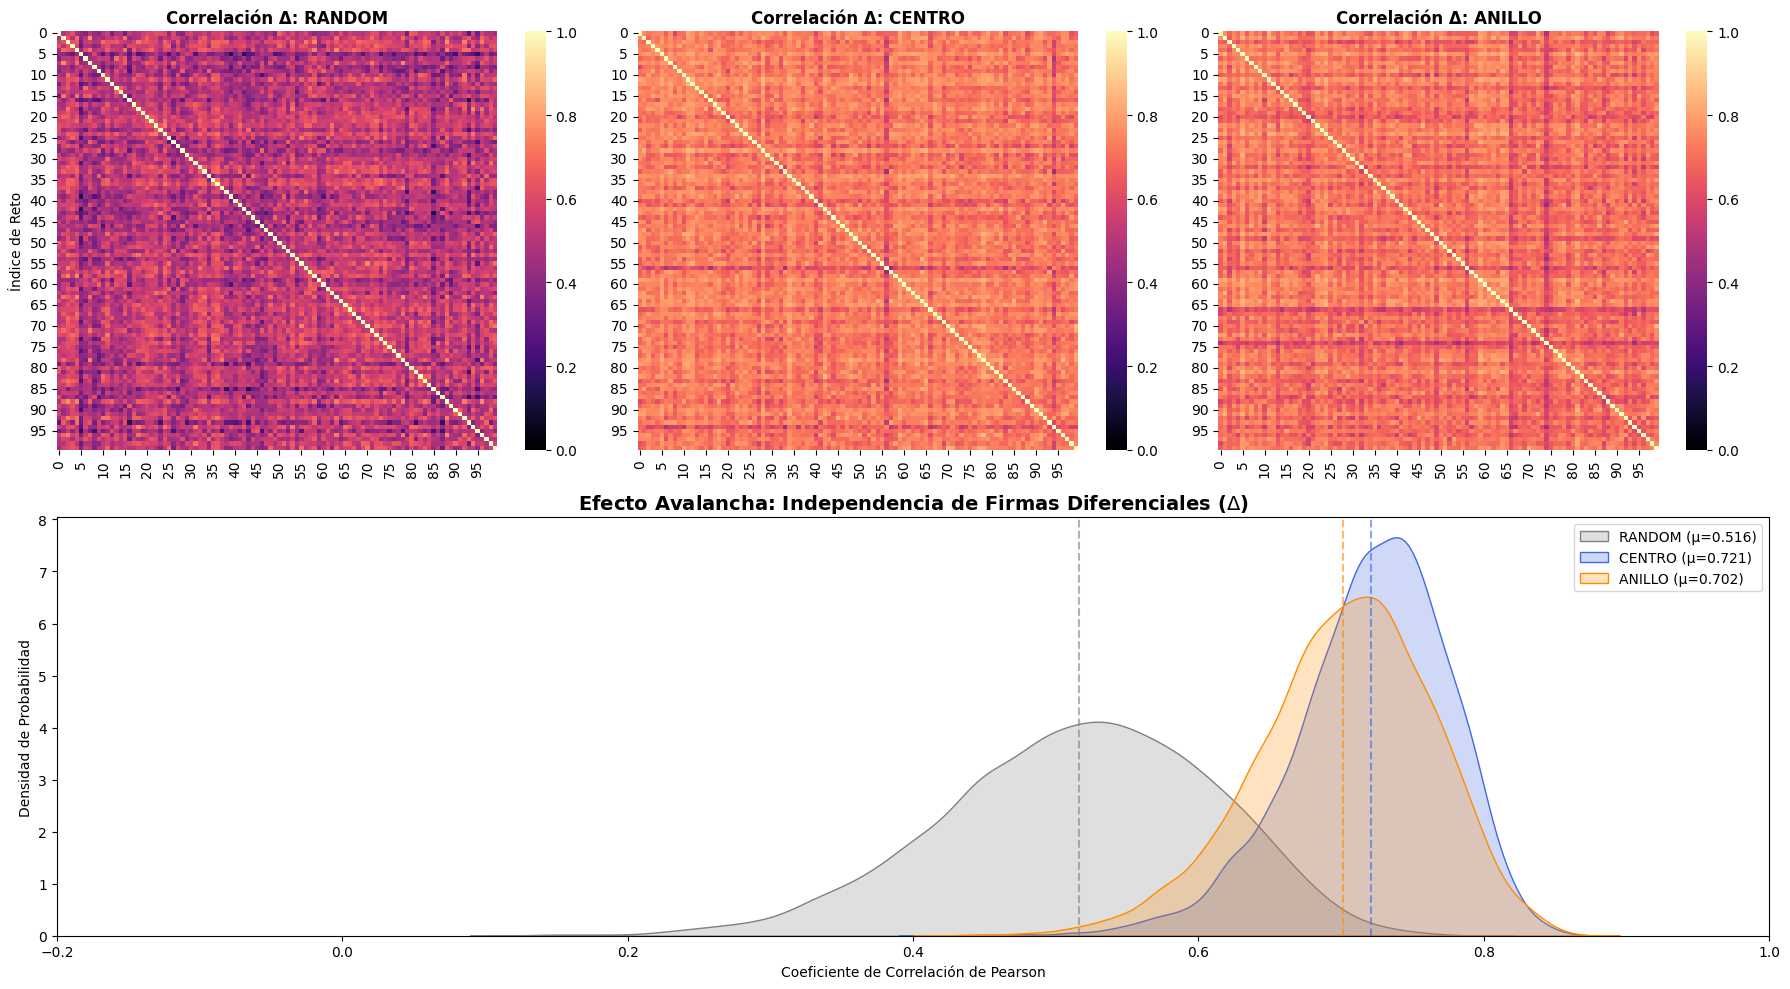

--------------------------------------------------
ESCENARIO (Δ)   | MEDIA CORR   | MAX CORR  
--------------------------------------------------
RANDOM          |       0.5162 |     0.7694
CENTRO          |       0.7209 |     0.8647
ANILLO          |       0.7017 |     0.8619
--------------------------------------------------


In [143]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN ---
directorio_data = "base_datos_puf_PRUEBA1" 
archivo_chip = "chip_5000.npz"
path = os.path.join(directorio_data, archivo_chip)

if not os.path.exists(path):
    print(f"❌ No se encuentra el archivo {path}")
else:
    data = np.load(path)
    escenarios = ['random', 'centro', 'anillo']
    colores = {'random': 'gray', 'centro': 'royalblue', 'anillo': 'darkorange'}
    resultados = {}

    # 1. Preparamos la BASE en dB (común para todos los retos del mismo chip)
    m_base_db = 10 * np.log10(data['base'] + 1e-12).flatten()

    plt.figure(figsize=(18, 10))

    for i, esc in enumerate(escenarios):
        potencias = data[esc] # (100, 28, 28)
        firmas_delta = []
        
        for j in range(len(potencias)):
            # 2. Calculamos la Firma Diferencial: Delta = Reto_dB - Base_dB
            m_reto_db = 10 * np.log10(potencias[j] + 1e-12).flatten()
            delta = m_base_db- m_reto_db 
            firmas_delta.append(delta)
        
        matriz_firmas = np.array(firmas_delta) # (100 retos x 784 puntos)

        # 3. Calcular Matriz de Correlación entre los Deltas
        corr_matrix = np.corrcoef(matriz_firmas)
        
        # 4. Extraer valores fuera de la diagonal
        indices_sup = np.triu_indices_from(corr_matrix, k=1)
        valores_corr = corr_matrix[indices_sup]
        resultados[esc] = valores_corr

        # --- VISUALIZACIÓN: MAPAS DE CALOR ---
        plt.subplot(2, 3, i + 1)
        sns.heatmap(corr_matrix, cmap='magma', vmin=0, vmax=1.0)
        plt.title(f"Correlación Δ: {esc.upper()}", fontweight='bold')
        if i == 0: plt.ylabel("Índice de Reto")

    # --- VISUALIZACIÓN: HISTOGRAMA COMPARATIVO ---
    plt.subplot(2, 1, 2)
    for esc in escenarios:
        sns.kdeplot(resultados[esc], fill=True, 
                    label=f"{esc.upper()} (μ={np.mean(resultados[esc]):.3f})", 
                    color=colores[esc])
        plt.axvline(np.mean(resultados[esc]), color=colores[esc], linestyle='--', alpha=0.6)

    plt.title("Efecto Avalancha: Independencia de Firmas Diferenciales ($\Delta$)", fontsize=14, fontweight='bold')
    plt.xlabel("Coeficiente de Correlación de Pearson")
    plt.ylabel("Densidad de Probabilidad")
    plt.legend()
    plt.xlim([-0.2, 1.0])

    plt.tight_layout()
    plt.show()

    # --- TABLA DE RESULTADOS POR CONSOLA ---
    print("-" * 50)
    print(f"{'ESCENARIO (Δ)':<15} | {'MEDIA CORR':<12} | {'MAX CORR':<10}")
    print("-" * 50)
    for esc in escenarios:
        print(f"{esc.upper():<15} | {np.mean(resultados[esc]):>12.4f} | {np.max(resultados[esc]):>10.4f}")
    print("-" * 50)

In [ ]:
import numpy as np
import bchlib
import hashlib
import math

# --- CONFIGURACIÓN ESTRATÉGICA ---
# Usamos m=12 para manejar los 3,052 bits y t=80 para una robustez del 2.6%
BCH_POLYNOMIAL = 8219 # Estándar para m=12
BCH_T = 80
BCH_M = 12
bch = bchlib.BCH(t=BCH_T, m=BCH_M)

def binarizar_malla_por_columnas(matriz_db):
    """
    Recorre las 28 columnas y genera la cadena de 3,052 bits.
    """
    bitstring_total = ""
    for j in range(matriz_db.shape[1]):
        columna = matriz_db[:, j]
        # Usamos tu función optimizada
        bits_col, _, _ = binarización_optimizada(columna)
        bitstring_total += bits_col
    return bitstring_total

def enrollment_proceso(malla, id_reto_challenge):
    """
    Simula el registro inicial del chip en el servidor.
    """
    # 1. Captura de ADN Físico (Simulamos lectura sin ruido en fábrica)
    # M_Base: El chip tal cual (usamos un reto 'i' como su estado natural)
    malla.programar_malla([]) # Estado por defecto
    m_base = 10 * np.log10(np.abs(malla.resolver_matriz_total(ids_40))**2 + 1e-12)
    
    # M_Challenge: El chip ante el reto de autenticación
    config_challenge = generar_configuracion_totalmente_aleatoria(malla, seed=id_reto_challenge)
    malla.programar_malla(config_challenge)
    m_challenge = 10 * np.log10(np.abs(malla.resolver_matriz_total(ids_40))**2 + 1e-12)
    
    # 2. Firma Diferencial (Limpieza de ruido sistemático)
    delta_maestra = m_challenge - m_base
    
    # 3. Extracción de Bits (Lehmer por columnas)
    bitstring = binarizar_malla_por_columnas(delta_maestra)
    bits_lista = [int(b) for b in bitstring]
    
    # 4. Fuzzy Extractor (Protección)
    # Convertimos a bytes (con padding para el BCH)
    data_bytes = bits_to_bytes_local(rellenar_a_byte(bits_lista))
    helper_data = bch.encode(data_bytes) # Los 120 bytes de 'pista'
    
    # 5. Generación de Hash
    hash_maestro = hashlib.sha256(data_bytes).hexdigest()
    
    return helper_data, hash_maestro

# --- FASE 2: AUTENTICACIÓN (EN EL CAMPO / USO REAL) ---

def autenticacion_proceso(malla, id_reto_challenge, helper_data, hash_maestro, sigma_ruido=0.05):
    """
    Simula el intento de acceso de un chip con ruido ambiental.
    """
    # 1. Doble Lectura Ruidosa
    # El chip mide su Base y su Challenge añadiendo ruido térmico/fase
    malla.programar_malla([])
    m_base_ruido = 10 * np.log10(np.abs(malla.resolver_matriz_total(ids_40))**2 + 1e-12)
    m_base_ruido += np.random.normal(0, sigma_ruido, m_base_ruido.shape)
    
    config_challenge = generar_configuracion_totalmente_aleatoria(malla, seed=id_reto_challenge)
    malla.programar_malla(config_challenge)
    m_challenge_ruido = 10 * np.log10(np.abs(malla.resolver_matriz_total(ids_40))**2 + 1e-12)
    m_challenge_ruido += np.random.normal(0, sigma_ruido, m_challenge_ruido.shape)
    
    # 2. Firma Diferencial Ruidosa
    delta_ruidosa = m_challenge_ruido - m_base_ruido
    
    # 3. Binarización de Intento
    bitstring_r = binarizar_malla_por_columnas(delta_ruidosa)
    bits_r_lista = [int(b) for b in bitstring_r]
    
    # 4. Reconstrucción BCH (Uso de Helper Data)
    data_r_bytes = bytearray(bits_to_bytes_local(rellenar_a_byte(bits_r_lista)))
    
    # El BCH intenta limpiar los errores basándose en el helper_data
    n_err = bch.decode(data_r_bytes, bytearray(helper_data))
    if n_err >= 0:
        bch.correct(data_r_bytes, bytearray(helper_data))
        
    # 5. Verificación de Hash
    hash_intento = hashlib.sha256(data_r_bytes).hexdigest()
    
    return hash_intento == hash_maestro, n_err

# --- PRUEBA DEL SISTEMA ---
# Creamos el Chip 5000
chip_real = malla_SNM_completa(tbus_columnas, seed=5000)

print("🏭 Iniciando Enrollment en Fábrica...")
h_data, h_maestro = enrollment_proceso(chip_real, id_reto_challenge=999)

print("📱 Intentando Autenticación en el mundo real...")
exito, errores_corregidos = autenticacion_proceso(chip_real, 999, h_data, h_maestro)

if exito:
    print(f"✅ ACCESO CONCEDIDO. Errores corregidos por BCH: {errores_corregidos}")
else:
    print(f"❌ ACCESO DENEGADO. El ruido superó la capacidad del sistema.")